# Lag Feature Nedir?

**Lag feature** (gecikmeli özellik), zaman serisi analizinde ve makine öğrenmesi modellerinde, bir değişkenin **geçmiş zaman adımlarındaki değerlerini** bugünü veya geleceği tahmin etmek için model girdisi (feature) olarak kullanma tekniğidir.

En yalın ifadeyle: **"Bugünü ya da yarını tahmin etmek için düne ($t-1$), önceki güne ($t-2$) veya geçen haftaki aynı güne ($t-7$) bakmaktır."**

---

## Nasıl Çalışır? (Örnekle)

Diyelim ki bir mağazanın günlük dondurma satışlarını tahmin etmek istiyorsunuz:

| Tarih | Gerçek Satış ($y_t$) | Lag 1 ($t-1$) | Lag 2 ($t-2$) | Lag 7 ($t-7$) |
| --- | --- | --- | --- | --- |
| **1 Temmuz** | 100 | NaN | NaN | NaN |
| **2 Temmuz** | 120 | 100 | NaN | NaN |
| **3 Temmuz** | 115 | 120 | 100 | NaN |
| **...** | ... | ... | ... | ... |
| **8 Temmuz** | **140** | **130** *(7 Temmuz)* | **125** *(6 Temmuz)* | **100** *(1 Temmuz)* |

Burada:

* **Lag 1:** Bir önceki günün satış miktarı.
* **Lag 2:** İki gün önceki satış miktarı.
* **Lag 7:** Tam bir hafta önceki (aynı günün) satış miktarı (mevsimselliği yakalamak için harikadır).

---

## Neden Kullanılır?

1. **Zaman Bağımlılığını Yakalar:** Klasik makine öğrenmesi algoritmaları (XGBoost, LightGBM, Random Forest vb.) verinin zaman sırasını varsayılan olarak bilmez. Lag feature'lar verideki **otokorelasyonu** (geçmişin gelecekle olan ilişkisini) bu modellere tanıtır.

2. **Trend ve Mevsimsellik:** Kısa vadeli trendleri (ör. son 3 gündür artış var mı?) ve periyodik desenleri (ör. her hafta sonu satışlar düşüyor mu?) yakalamayı sağlar.

---

## Pandas ile Nasıl Oluşturulur?

Python'da Pandas kütüphanesinin `.shift()` metodunu kullanarak kolayca lag feature üretebilirsiniz:

```python
import pandas as pd

# Örnek DataFrame
df = pd.DataFrame({'satis': [100, 120, 115, 130, 140]})

# 1 ve 2 adımlık lag oluşturma
df['lag_1'] = df['satis'].shift(1)
df['lag_2'] = df['satis'].shift(2)

print(df)

```

---

## Dikkat Edilmesi Gerekenler

* **`NaN` Değerler:** Öteleme yapıldığı için ilk zaman adımlarında boş (`NaN`) değerler oluşur. Bunları düşürmek (`dropna()`) veya uygun şekilde doldurmak gerekir.

* **Veri Sızıntısı (Data Leakage):** Tahmin yapmak istediğiniz an henüz gerçekleşmemiş bir geleceğin lag'ini modele vermediğinizden emin olmalısınız.

In [1]:
import pandas as pd

data = pd.read_csv(
    "../data/processed/google_trends_ai_3y_clean.csv",
    index_col="date",
    parse_dates=True,
)

chatgpt = data["chatgpt"]

chatgpt.tail()

date
2026-06-28    65
2026-07-05    65
2026-07-12    65
2026-07-19    69
2026-07-26    66
Name: chatgpt, dtype: int64

In [9]:
from scipy.fftpack import shift


lag_data = pd.DataFrame(
    {
        "target": chatgpt,
        "lag_1": chatgpt.shift(1),
        "lag_2": chatgpt.shift(2),
        "lag_3": chatgpt.shift(3),
        "lag_4": chatgpt.shift(4),

    }
)
print(lag_data.shape)
lag_data.head(10)

(157, 5)


,target,lag_1,lag_2,lag_3,lag_4
date,,,,,
2023-07-30,13,NaN,NaN,NaN,NaN
2023-08-06,14,13.0,NaN,NaN,NaN
2023-08-13,14,14.0,13.0,NaN,NaN
2023-08-20,15,14.0,14.0,13.0,NaN
2023-08-27,16,15.0,14.0,14.0,13.0
2023-09-03,16,16.0,15.0,14.0,14.0
2023-09-10,18,16.0,16.0,15.0,14.0
2023-09-17,18,18.0,16.0,16.0,15.0
2023-09-24,20,18.0,18.0,16.0,16.0


Buradaki yeni şey .shift().

chatgpt.shift(1)

demek:

ChatGPT değerlerini 1 satır aşağı kaydır.

Böylece mevcut haftanın satırına bir önceki haftanın değeri gelir.

shift(2) iki hafta öncesini, shift(4) dört hafta öncesini getirir.

### Lag Verisinin Hazırlanması

Lag feature'ların oluşturulması sırasında ilk haftalarda yeterli geçmiş veri
bulunmadığı için `NaN` değerler oluşur. Bu satırlar kaldırıldıktan sonra
geçmiş hafta değerleri model girdileri (`X`), mevcut haftanın değeri ise
tahmin edilmek istenen hedef (`y`) olarak ayrılır. Burda 4 tane NaN olan satır vardı.

In [6]:
lag_data = lag_data.dropna()

X = lag_data[
    ["lag_1", "lag_2", "lag_3", "lag_4"]
]

y = lag_data["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()


X shape: (153, 4)
y shape: (153,)


,lag_1,lag_2,lag_3,lag_4
date,,,,
2023-08-27,15.0,14.0,14.0,13.0
2023-09-03,16.0,15.0,14.0,14.0
2023-09-10,16.0,16.0,15.0,14.0
2023-09-17,18.0,16.0,16.0,15.0
2023-09-24,18.0,18.0,16.0,16.0


In [7]:
y.head()

date
2023-08-27    16
2023-09-03    16
2023-09-10    18
2023-09-17    18
2023-09-24    20
Name: target, dtype: int64

2023-08-27

lag_1 = 15   → 1 hafta önce
lag_2 = 14   → 2 hafta önce
lag_3 = 14   → 3 hafta önce
lag_4 = 13   → 4 hafta önce

target = 16  → o haftanın gerçek değeri

Yani XGBoost geçmişte buna benzer birçok örneğe bakarak “son haftalar böyleyse sonraki değer ne olabilir?” ilişkisini öğrenmeye çalışacak. XGBRegressor, XGBoost’un sayısal değer tahmini için kullanılan scikit-learn uyumlu regresyon modelidir.

Ama modeli çalıştırmadan önce önemli bir nokta var: 4 haftalık tahminde test verisini doğrudan X_test olarak veremeyiz.

## XGboost ne yapçak?

Şunu demek istiyorum: **XGBoost’a lag’leri nasıl vereceğimiz, 4 haftayı tek seferde tahmin ederken önemli.**

Diyelim son bildiğimiz gerçek değerler:

```text
Son 4 hafta:
60, 62, 65, 64
```

Ve bundan sonraki **4 haftayı** tahmin edeceğiz.

İlk haftayı tahmin etmek kolay:

```text
lag_1 = 64
lag_2 = 65
lag_3 = 62
lag_4 = 60

→ XGBoost tahmini: 66
```

Şimdi **2. haftayı** tahmin edeceğiz. Burada sorun şu: 1. haftanın gerçek değerini henüz bilmiyoruz. Çünkü biz 4 haftalık geleceği daha en baştan tahmin ediyoruz.

O yüzden:

```text
lag_1 = 66   ← az önceki tahminimiz
lag_2 = 64   ← gerçek
lag_3 = 65   ← gerçek
lag_4 = 62   ← gerçek

→ 2. hafta tahmini: örneğin 67
```

Sonra 3. hafta:

```text
lag_1 = 67   ← tahmin
lag_2 = 66   ← tahmin
lag_3 = 64   ← gerçek
lag_4 = 65   ← gerçek
```

Böyle böyle ilerliyoruz.

Buna **recursive forecasting** deniyor: model bir sonraki haftayı tahmin ediyor, sonra kendi tahminini sonraki tahminde girdi olarak kullanıyor.

Neden bunu yapıyoruz? Çünkü gerçek hayatta 26 Temmuz’da durup:

> “Önümüzdeki 4 haftayı tahmin et.”

deseydik, 2 Ağustos’un gerçek değerini daha bilmiyor olacaktık. Dolayısıyla 9 Ağustos’u tahmin ederken 2 Ağustos’un gerçek değerini kullanmak **hile gibi olurdu**; gelecekte henüz bilmediğimiz bilgiyi modele vermiş olurduk.

Yani şu fark var:

```text
YANLIŞ / fazla kolay:
1. haftayı tahmin et → sonra 1. haftanın gerçek değerini kullan
2. haftayı tahmin et → sonra 2. haftanın gerçek değerini kullan
```

Bu aslında her seferinde sadece **1 hafta ileri** tahmin etmiş olur.

Bizim istediğimiz:

```text
Bugün dur
↓
1., 2., 3. ve 4. haftayı
bugün bildiğin bilgilerle tahmin et
```

Çünkü Prophet ve ARIMA’yı da **4 haftalık horizon** için böyle değerlendirdik.

Kısacası şu an aklında sadece bunu tut: **XGBoost 4 hafta geleceği tahmin ederken, ilerleyen haftalarda kendi önceki tahminlerini lag olarak kullanacak.** Henüz koduna geçmedik.


In [22]:


import xgboost

print(xgboost.__version__)

3.4.0


In [23]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [24]:
# en son 4 haftayı test olarak ayıralım:
train_X = X.iloc[:-4]
test_X = X.iloc[-4:]

train_y = y.iloc[:-4]
test_y = y.iloc[-4:]

Ama burada test_Xi direkt kullanmayacağız. Çünkü az önce konuştuğumuz gibi 2., 3. ve 4. haftada geleceğin gerçek lag değerlerini bilmiyor olacağız.

In [25]:
# Önce modeli eğitelim:
model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)

model.fit(train_X, train_y)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [26]:
# Ardından recursive tahmin için:

history = list(train_y.iloc[-4:])
predictions = []

for _ in range(4):
    current_features = pd.DataFrame(
        [[
            history[-1],
            history[-2],
            history[-3],
            history[-4],
        ]],
        columns=["lag_1", "lag_2", "lag_3", "lag_4"],
    )

    prediction = model.predict(current_features)[0]

    predictions.append(prediction)
    history.append(prediction)

In [27]:
# Sonra gerçeklerle karşılaştıralım:

comparison = pd.DataFrame(
    {
        "actual": test_y.values,
        "predicted": predictions,
    },
    index=test_y.index,
)

comparison

,actual,predicted
date,,
2026-07-05,65,66.192192
2026-07-12,65,68.812599
2026-07-19,69,69.079498
2026-07-26,66,70.841187


ilk XGBoost tahminimiz çalıştı. Burada özellikle recursive forecasting’in etkisini görebiliyoruz:

Tarih         Gerçek    Tahmin
05 Temmuz       65       66.19
12 Temmuz       65       68.81
19 Temmuz       69       69.08
26 Temmuz       66       70.84

İlk hafta model gerçek geçmiş değerlerle başladı ve 66.19 tahmin etti. Sonraki haftalarda artık kendi önceki tahminlerini de lag olarak kullanmaya başladığı için tahminler biraz yukarı doğru sürüklendi. Mesela son hafta gerçek değer 66 iken model 70.84 tahmin etmiş.

Bu, recursive yöntemin önemli bir özelliği: erken yapılan bir hata sonraki tahminleri de etkileyebilir. Çünkü tahmin edilen değer tekrar modele girdi oluyor.

Şimdi bu tek 4 haftalık dönemin MAE ve RMSE’sini hesaplayalım:

In [28]:
xgb_mae = mean_absolute_error(
    test_y,
    predictions,
)

xgb_rmse = root_mean_squared_error(
    test_y,
    predictions,
)

print("XGBoost MAE:", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)

XGBoost MAE: 2.4813690185546875
XGBoost RMSE: 3.138496511330586


İlk deneme için sonuç gayet iyi görünüyor:

XGBoost — son 4 hafta
MAE  = 2.481
RMSE = 3.138

Ama burada önemli nokta: bu sadece son 4 haftalık tek fold. Bu yüzden henüz “XGBoost Prophet’ten iyi” diyemeyiz.

Hatta elimizde aynı son 4 haftaya ait önceki sonuçlar da vardı:

Son fold:
Naive             MAE ≈ 1.25
ARIMA(1,1,1)      MAE ≈ 1.40
Prophet            MAE ≈ 2.43
XGBoost            MAE ≈ 2.48

Yani bu özel 4 haftada XGBoost aslında en iyi değil. Ama bazı diğer dönemlerde çok daha iyi olabilir. Bu yüzden yine 12 fold ortalamasına bakmamız gerekiyor.

Şimdi XGBoost’u bizim diğer modellerle aynı 12 fold × 4 hafta sisteminde değerlendirelim.

In [29]:
from sklearn.model_selection import TimeSeriesSplit

tscv_xgb = TimeSeriesSplit(
    n_splits=12,
    test_size=4,
)

In [30]:
xgb_cv_results = []

for fold, (train_index, test_index) in enumerate(
    tscv_xgb.split(X),
    start=1,
):
    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
    )

    model.fit(X_train, y_train)

    history = list(y_train.iloc[-4:])
    predictions = []

    for _ in range(4):
        current_features = pd.DataFrame(
            [[
                history[-1],
                history[-2],
                history[-3],
                history[-4],
            ]],
            columns=[
                "lag_1",
                "lag_2",
                "lag_3",
                "lag_4",
            ],
        )

        prediction = model.predict(
            current_features
        )[0]

        predictions.append(prediction)
        history.append(prediction)

    mae = mean_absolute_error(
        y_test,
        predictions,
    )

    rmse = root_mean_squared_error(
        y_test,
        predictions,
    )

    xgb_cv_results.append(
        {
            "fold": fold,
            "MAE": mae,
            "RMSE": rmse,
        }
    )

In [31]:
# şimdi tablo:

xgb_cv_df = pd.DataFrame(
    xgb_cv_results
)

xgb_cv_df

,fold,MAE,RMSE
0,1,13.935900,14.935054
1,2,8.298733,8.868367
2,3,1.705257,2.100501
3,4,7.647638,7.654068
4,5,11.568214,14.265731
5,6,1.491081,1.731996
6,7,5.071842,5.539883
7,8,3.685558,4.070132
8,9,1.328354,1.400451
9,10,2.120422,2.252869


In [32]:
xgb_cv_df[
    ["MAE", "RMSE"]
].mean()

MAE     5.218387
RMSE    5.832175
dtype: float64

Bu sonuç önemli çünkü şimdi XGBoost’u gerçekten adil şekilde değerlendirmiş olduk.

```text
XGBoost
MAE  = 5.218
RMSE = 5.832
```

Şu anki 4 haftalık CV karşılaştırmamız:

```text
Prophet (cps=1.0)   MAE 4.30   RMSE 4.83
ARIMA(1,1,1)        MAE 4.41   RMSE 5.00
Naive               MAE 4.54   RMSE 5.24
XGBoost             MAE 5.22   RMSE 5.83
```

Yani **şu anki haliyle XGBoost en kötü sonuç veren model**.

Ama bu kötü bir şey değil; bize şunu öğretiyor: sadece son 4 haftaya bakınca XGBoost çok iyi görünmüştü (`MAE 2.48`), fakat farklı dönemlerde test edince o başarı genellenmiyor. İşte cross-validation yapmamızın asıl sebebi buydu.

Bunun birkaç olası nedeni var: sadece `lag_1`–`lag_4` kullanıyoruz, veri setimiz küçük, XGBoost’un parametrelerini hiç ayarlamadık ve recursive tahminde ilk haftadaki hata sonraki haftalara taşınabiliyor.

Şimdi bence direkt “XGBoost kötü, bırakalım” demeyelim. Önce **hangi foldlarda kötüleştiğini** görelim:

```python
xgb_cv_df
```

Bir de en kötüden iyiye sırala:

```python
xgb_cv_df.sort_values(
    "MAE",
    ascending=False,
)
```

Bunu gönder. Özellikle bir-iki fold aşırı kötü olup ortalamayı mı bozuyor, yoksa XGBoost genel olarak mı zayıf, onu anlayalım. Sonra lag sayısını artırmanın mı yoksa XGBoost parametrelerini ayarlamanın mı daha mantıklı olduğuna karar veririz.


In [33]:
xgb_cv_df

,fold,MAE,RMSE
0,1,13.935900,14.935054
1,2,8.298733,8.868367
2,3,1.705257,2.100501
3,4,7.647638,7.654068
4,5,11.568214,14.265731
5,6,1.491081,1.731996
6,7,5.071842,5.539883
7,8,3.685558,4.070132
8,9,1.328354,1.400451
9,10,2.120422,2.252869


In [35]:
xgb_cv_df.sort_values(
    "MAE",
    ascending=False,
).reset_index(drop=True)

,fold,MAE,RMSE
0,1,13.935900,14.935054
1,5,11.568214,14.265731
2,2,8.298733,8.868367
3,4,7.647638,7.654068
4,7,5.071842,5.539883
5,8,3.685558,4.070132
6,11,3.286272,4.028554
7,12,2.481369,3.138497
8,10,2.120422,2.252869
9,3,1.705257,2.100501


Şimdi tablo net. Burada XGBoost için ilginç bir durum var: **model her dönemde kötü değil; birkaç dönemde çok kötüleşiyor.**

Mesela:

```text
Fold 1  → MAE 13.94   ❌
Fold 5  → MAE 11.57   ❌
Fold 2  → MAE  8.30   ❌
Fold 4  → MAE  7.65   ❌

ama

Fold 9  → MAE 1.33    ✅
Fold 6  → MAE 1.49    ✅
Fold 3  → MAE 1.71    ✅
Fold 10 → MAE 2.12    ✅
Fold 12 → MAE 2.48    ✅
```

Hatta 12 foldun **ortanca (median) MAE’si yaklaşık 3.49**. Ortalama ise `5.22`. Yani birkaç büyük hata ortalamayı ciddi şekilde yukarı çekiyor.

Bu bize şunu söylüyor:

> XGBoost bazı dönemlerde serinin davranışını çok iyi yakalıyor ama bazı trend/seviye değişimlerinde ciddi şekilde şaşırıyor.

Dolayısıyla şu anda “XGBoost genel olarak beceremiyor” demek yerine **“XGBoost’un performansı dönemlere göre çok değişken”** demek daha doğru.

Ve bu aslında önemli. Gerçek hayatta modelin “10 dönemin 7’sinde çok iyiyim ama bazen çok kötü tahmin yapıyorum” demesi riskli olabilir. O yüzden o kötü foldları yok sayamayız.

Şimdi bence hemen parametreleri kurcalamadan önce **Fold 1 ve Fold 5’te XGBoost ne tahmin etmiş, gerçek değerler neymiş** görelim. Böylece sorun “ani düşüş mü, yükseliş mi, recursive tahminlerin birbirini sürüklemesi mi?” anlayacağız.

Notebook’a bunu çalıştır:

```python
for selected_fold in [1, 5]:
    train_index, test_index = list(
        tscv_xgb.split(X)
    )[selected_fold - 1]

    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
    )

    model.fit(X_train, y_train)

    history = list(y_train.iloc[-4:])
    predictions = []

    for _ in range(4):
        current_features = pd.DataFrame(
            [[
                history[-1],
                history[-2],
                history[-3],
                history[-4],
            ]],
            columns=["lag_1", "lag_2", "lag_3", "lag_4"],
        )

        prediction = model.predict(current_features)[0]

        predictions.append(prediction)
        history.append(prediction)

    comparison = pd.DataFrame(
        {
            "actual": y_test.values,
            "predicted": predictions,
        },
        index=y_test.index,
    )

    print(f"\nFold {selected_fold}")
    display(comparison)
```


In [36]:
for selected_fold in [1, 5]:
    train_index, test_index = list(
        tscv_xgb.split(X)
    )[selected_fold - 1]

    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
    )

    model.fit(X_train, y_train)

    history = list(y_train.iloc[-4:])
    predictions = []

    for _ in range(4):
        current_features = pd.DataFrame(
            [[
                history[-1],
                history[-2],
                history[-3],
                history[-4],
            ]],
            columns=["lag_1", "lag_2", "lag_3", "lag_4"],
        )

        prediction = model.predict(current_features)[0]

        predictions.append(prediction)
        history.append(prediction)

    comparison = pd.DataFrame(
        {
            "actual": y_test.values,
            "predicted": predictions,
        },
        index=y_test.index,
    )

    print(f"\nFold {selected_fold}")
    display(comparison)


Fold 1


,actual,predicted
date,,
2025-08-31,79,71.774956
2025-09-07,85,70.561615
2025-09-14,91,68.918777
2025-09-21,79,67.001053



Fold 5


,actual,predicted
date,,
2025-12-21,57,75.318214
2025-12-28,54,75.318214
2026-01-04,71,75.318214
2026-01-11,73,75.318214


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Sadece o döneme daha yakından bakmak için son train kısmını ve test kısmını çizdirelim
plt.plot(chatgpt.iloc[train_index][-20:], label="Eğitim (Train) - Son 20 Hafta", color="blue")
plt.plot(fold5_test, label="Test (Fold 5) - Tahmin Edilmeye Çalışılan", color="red", marker="o")

plt.title("Fold 5 Dönemi: Neden Çuvalladık?")
plt.legend()
plt.grid(True)
plt.show()


Fold 1


,actual,predicted
date,,
2025-08-31,79,71.774956
2025-09-07,85,70.561615
2025-09-14,91,68.918777
2025-09-21,79,67.001053


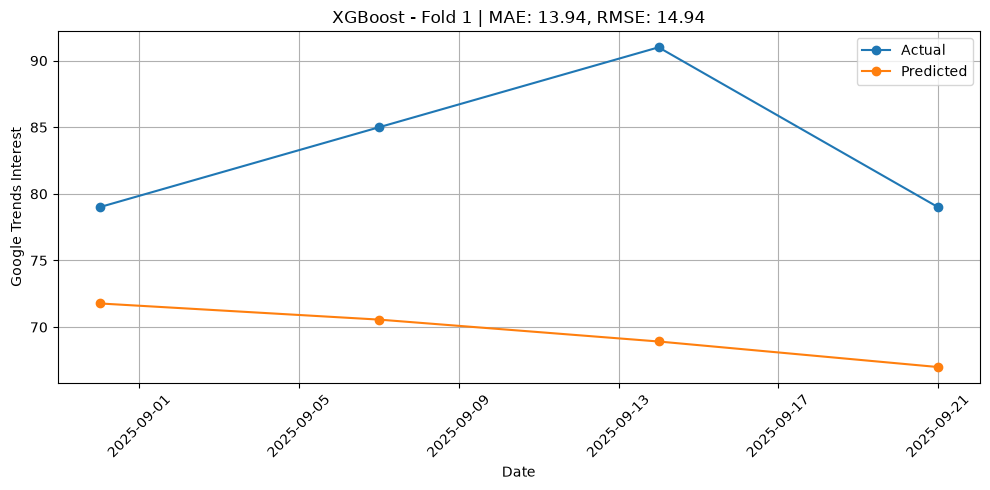


Fold 5


,actual,predicted
date,,
2025-12-21,57,75.318214
2025-12-28,54,75.318214
2026-01-04,71,75.318214
2026-01-11,73,75.318214


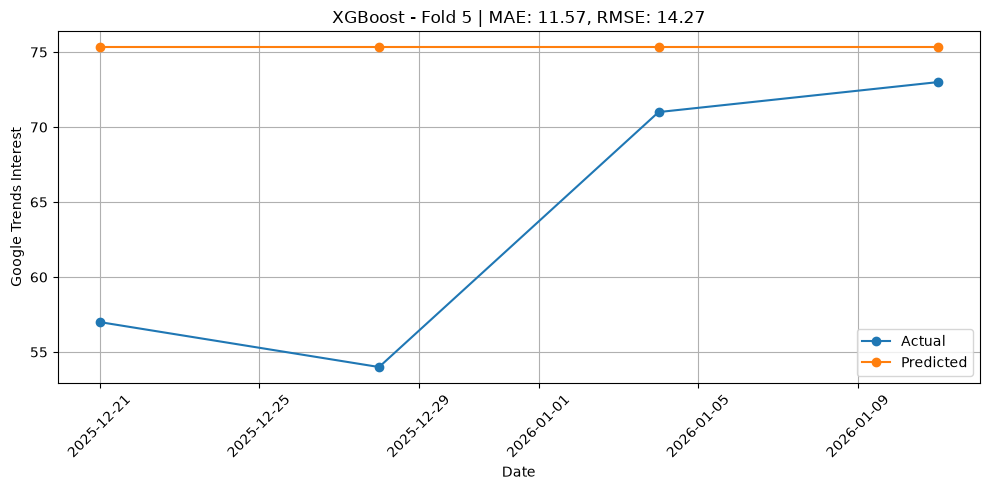

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

selected_folds = [1, 5]

for selected_fold in selected_folds:
    train_index, test_index = list(tscv_xgb.split(X))[selected_fold - 1]

    X_train = X.iloc[train_index]
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
    )

    model.fit(X_train, y_train)

    history = list(y_train.iloc[-4:])
    predictions = []

    for _ in range(len(y_test)):
        current_features = pd.DataFrame(
            [[
                history[-1],
                history[-2],
                history[-3],
                history[-4],
            ]],
            columns=["lag_1", "lag_2", "lag_3", "lag_4"],
        )

        prediction = model.predict(current_features)[0]
        predictions.append(prediction)
        history.append(prediction)

    comparison = pd.DataFrame(
        {
            "actual": y_test.values,
            "predicted": predictions,
        },
        index=y_test.index,
    )

    mae = mean_absolute_error(y_test, predictions)
    rmse = root_mean_squared_error(y_test, predictions)

    print(f"\nFold {selected_fold}")
    display(comparison)

    plt.figure(figsize=(10, 5))
    plt.plot(comparison.index, comparison["actual"], marker="o", label="Actual")
    plt.plot(comparison.index, comparison["predicted"], marker="o", label="Predicted")
    plt.title(f"XGBoost - Fold {selected_fold} | MAE: {mae:.2f}, RMSE: {rmse:.2f}")
    plt.xlabel("Date")
    plt.ylabel("Google Trends Interest")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [48]:
fold_1_train_index, fold_1_test_index = list(
    tscv_xgb.split(X)
)[0]

fold_1_X_train = X.iloc[fold_1_train_index]
fold_1_y_train = y.iloc[fold_1_train_index]

fold_1_X_test = X.iloc[fold_1_test_index]
fold_1_y_test = y.iloc[fold_1_test_index]

In [49]:
fold_1_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)

fold_1_model.fit(
    fold_1_X_train,
    fold_1_y_train,
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [50]:
# Bu bize eğitim setinin son satırındaki lag değerlerini gösterecek.
fold_1_train_index, fold_1_test_index = list(
    tscv_xgb.split(X)
)[0]

fold_1_X_train = X.iloc[fold_1_train_index]
fold_1_y_train = y.iloc[fold_1_train_index]
fold_1_y_test = y.iloc[fold_1_test_index]

fold_1_last_lags = fold_1_X_train.iloc[-1]

fold_1_last_lags

lag_1    75.0
lag_2    72.0
lag_3    77.0
lag_4    72.0
Name: 2025-08-24 00:00:00, dtype: float64

In [51]:
# a ilk test haftasını tahmin ederken gerçekten kullanılan değerleri daha açık görmek için şunu da yap:

history = list(fold_1_y_train.iloc[-4:])

history

[77, 72, 75, 79]

Bu dört sayı şunlar:

history[-1] → lag_1
history[-2] → lag_2
history[-3] → lag_3
history[-4] → lag_4

In [55]:
first_features = pd.DataFrame(
    [[
        history[-1],
        history[-2],
        history[-3],
        history[-4],
    ]],
    columns=["lag_1", "lag_2", "lag_3", "lag_4"],
)

first_features

#Bu tablo aslında modele sorduğumuz ilk soru:

#Son 4 gerçek hafta böyleyken, 31 Ağustos değeri ne olur?”

,lag_1,lag_2,lag_3,lag_4
0,79,75,72,77


In [54]:
first_prediction = fold_1_model.predict(
    first_features
)[0]

first_prediction

np.float32(71.774956)

Evet, tam burada beyin fırtınası yapmak mantıklı. Biz şu an XGBoost’a oldukça **basit bir ilk model** verdik:

```python
XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)
```

Burada modeli iyileştirmek için aslında **iki ayrı şeyi** değiştirebiliriz:

**1) Modelin kendisini nasıl öğrendiğini değiştirmek** → `max_depth`, `n_estimators`, `learning_rate` gibi parametreler.
**2) Modele verdiğimiz bilgiyi değiştirmek** → sadece `lag_1...lag_4` yerine daha fazla lag, değişim miktarı, ortalama gibi feature’lar eklemek.

Bence ikincisi bizim problemimizde en az birincisi kadar önemli.

### Önce `max_depth`

`max_depth`, **her karar ağacının ne kadar dallanabileceğini** belirliyor. XGBoost dokümantasyonunda da bir ağacın maksimum derinliği olarak tanımlanıyor; derinlik arttıkça model daha karmaşık ilişkiler öğrenebiliyor ama fazla büyütmek eğitim verisine aşırı uyma riskini artırıyor. ([XGBoost Belgeleri][1])

Biz:

```python
max_depth=3
```

dedik.

Şöyle düşün:

```text
                    Soru 1
                   /     \
              Soru 2     Soru 2
              /   \       /   \
         Soru 3  ...    Soru 3 ...
```

Yani bir yol boyunca en fazla yaklaşık 3 seviyelik ayrım yapabiliyor.

Mesela basit bir ağaç şunları öğrenebilir:

```text
lag_1 > 70 mi?
       ↓ evet
lag_2 > 65 mi?
       ↓ evet
lag_4 < 75 mi?
       ↓
bir tahmin
```

Ama diyelim gerçek ilişki daha karmaşık:

```text
lag_1 > 70
VE
lag_2 > 65
VE
lag_3 > 60
VE
lag_4 < 75
VE
başka bir koşul...
```

`max_depth=3` bunu yeterince ayrıntılı ayıramayabilir.

O yüzden akla şu gelir:

```text
depth 2 → daha basit
depth 3 → şu anki
depth 4 → biraz daha karmaşık
depth 5 → daha karmaşık
```

Ama **“Fold 1 kötü → depth’i kesin artır”** diyemeyiz. Çünkü modelin sorunu belki yeterince karmaşık olmaması değil, ona yeterli bilgi vermememiz.

### `n_estimators`

Bu, az önce konuştuğumuz **kaç boosting ağacı kurulacağı**. Resmî API’de de boosted tree sayısı olarak tanımlanıyor. ([XGBoost Belgeleri][1])

Şu an:

```python
n_estimators=100
```

kullanıyoruz.

Beyin fırtınasında şunları düşünebiliriz:

```text
50
100
200
300
```

Daha fazla ağaç = modelin hataları düzeltmek için daha fazla turu var.

Ama yine:

```text
100 → 200
```

yapınca kesin iyileşecek diye bir şey yok.

---

### `learning_rate`

Bunu da gördük:

```python
learning_rate=0.05
```

Her yeni ağacın yaptığı düzeltmenin **ne kadar güçlü uygulanacağını** kontrol ediyor. XGBoost bunu boosting learning rate olarak tanımlıyor. ([XGBoost Belgeleri][2])

Kafanda:

```text
learning_rate büyük
→ her ağaç daha güçlü adım

learning_rate küçük
→ küçük küçük düzeltmeler
```

olsun.

Bu yüzden `learning_rate` ve `n_estimators` birbirine biraz bağlı düşünülür:

```text
küçük learning_rate
+
daha fazla ağaç
```

mantıklı bir kombinasyon olabilir.

Örneğin:

```text
learning_rate=0.1, n_estimators=100
```

ile

```text
learning_rate=0.03, n_estimators=300
```

farklı öğrenme biçimleri oluşturur.

---

Ama bence **bizim modelimiz için daha ilginç taraf feature’lar**.

Şu anda XGBoost’a yalnızca:

```text
lag_1
lag_2
lag_3
lag_4
```

veriyoruz.

Fold 1’de:

```text
79
75
72
77
```

gördü.

Ama biz insan olarak buna bakınca ayrıca şunu hesaplayabiliyoruz:

```text
son değişim:
79 - 75 = +4
```

Modelde ise `"son_değişim"` diye ayrı bir bilgi yok.

Mesela şöyle feature ekleyebiliriz:

```python
lag_data["change_1"] = (
    lag_data["lag_1"] - lag_data["lag_2"]
)
```

Fold 1 için bu:

```text
change_1 = +4
```

olurdu.

Hatta:

```text
lag_1 = 79
lag_2 = 75
lag_3 = 72
lag_4 = 77

change_1 = +4
change_2 = +3
```

gibi verirsek XGBoost’a sadece değerleri değil:

> “Son iki hareket +3 ve +4; yani yakın geçmişte yukarı yön var.”

bilgisini de daha açık şekilde vermiş oluruz.

Başka bir fikir **rolling mean**:

```text
son 4 haftanın ortalaması
```

Fold 1 için:

```text
(79 + 75 + 72 + 77) / 4
```

gibi.

Bu da modele:

> “Son dönem genel seviyesi yaklaşık nerede?”

bilgisini verir.

Bir de lag sayısını artırabiliriz:

```text
lag_1 ... lag_4   ← şu an

lag_1 ... lag_8

veya

lag_1 ... lag_12
```

Böylece model sadece bir aylık geçmişi değil, yaklaşık **2–3 aylık geçmişi** görebilir.

Bence şu aşamada olası denemeleri şöyle düşünelim:

| Değişiklik             | Modele ne kazandırabilir?                                                                             |
| ---------------------- | ----------------------------------------------------------------------------------------------------- |
| `max_depth`            | Daha karmaşık kurallar                                                                                |
| `n_estimators`         | Daha fazla düzeltme turu                                                                              |
| `learning_rate`        | Her düzeltmenin gücü                                                                                  |
| Daha fazla lag         | Daha uzun geçmiş                                                                                      |
| `change` feature       | Artıyor mu/azalıyor mu bilgisi                                                                        |
| Rolling mean           | Yakın geçmişin genel seviyesi                                                                         |
| `subsample`            | Her ağaçta verinin bir kısmını kullanarak modeli daha kontrollü hale getirme ([XGBoost Belgeleri][1]) |
| `reg_alpha/reg_lambda` | Modeli daha konservatif hale getiren regularization ([XGBoost Belgeleri][3])                          |

Ama **ben olsam ilk önce parametre tuning yapmazdım**.

Çünkü şu an Fold 1 analizinden çıkardığımız en güçlü şüphe:

> XGBoost’a yeterince zaman-serisi bilgisi vermiyoruz.

Yani önce şu soruyu test etmek bana daha bilimsel geliyor:

**“Aynı XGBoost parametrelerini hiç değiştirmeden, modele daha iyi feature verirsek 5.22 MAE düşüyor mu?”**

Mesela ilk kontrollü deneyimiz:

```text
Model A:
lag_1, lag_2, lag_3, lag_4
```

karşı:

```text
Model B:
lag_1 ... lag_8
```

olsun.

Sadece **bir şeyi değiştiririz**. İyileşirse neden iyileştiğini anlayabiliriz. Aynı anda depth, learning rate, lag sayısı, rolling mean hepsini değiştirirsek hangi değişikliğin işe yaradığını anlayamayız.

Bence sıradaki deney olarak **4 lag → 8 lag** yapalım. Sonra aynı 12-fold CV ile MAE/RMSE’ye bakalım. Eğer iyileşmezse `change` feature ekleriz. Bu şekilde adım adım ilerleriz.


In [56]:
lag_data_8 = pd.DataFrame(
    {
        "target": chatgpt,
        "lag_1": chatgpt.shift(1),
        "lag_2": chatgpt.shift(2),
        "lag_3": chatgpt.shift(3),
        "lag_4": chatgpt.shift(4),
        "lag_5": chatgpt.shift(5),
        "lag_6": chatgpt.shift(6),
        "lag_7": chatgpt.shift(7),
        "lag_8": chatgpt.shift(8),
    }
)

lag_data_8 = lag_data_8.dropna()

lag_data_8.head()

,target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8
date,,,,,,,,,
2023-09-24,20,18.0,18.0,16.0,16.0,15.0,14.0,14.0,13.0
2023-10-01,19,20.0,18.0,18.0,16.0,16.0,15.0,14.0,14.0
2023-10-08,20,19.0,20.0,18.0,18.0,16.0,16.0,15.0,14.0
2023-10-15,21,20.0,19.0,20.0,18.0,18.0,16.0,16.0,15.0
2023-10-22,20,21.0,20.0,19.0,20.0,18.0,18.0,16.0,16.0


In [57]:
X_8 = lag_data_8[
    [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_4",
        "lag_5",
        "lag_6",
        "lag_7",
        "lag_8",
    ]
]

y_8 = lag_data_8["target"]

print("X shape:", X_8.shape)
print("y shape:", y_8.shape)

X shape: (149, 8)
y shape: (149,)


4 lag kullanırken:

157 toplam hafta
- 4 başlangıç haftası
= 153 kullanılabilir satır

12 fold × 4 hafta = 48 test satırı olduğuna göre Fold 1:

153 - 48 = 105 eğitim satırı

oluyordu.

8 lag kullanınca:

157 toplam hafta
- 8 başlangıç haftası
= 149 kullanılabilir satır

Dolayısıyla Fold 1:

149 - 48 = 101 eğitim satırı

olacak.

Bu önemli çünkü diyelim:

4 lag MAE = 5.22
8 lag MAE = 4.90

çıktı.

“Kesin 8 lag daha iyi çünkü daha fazla geçmiş verdik” diyebiliriz, ama karşılaştırmada iki şey aynı anda değişmiş olur:

1. Feature sayısı 4 → 8 oldu
2. Eğitim örneği 105 → 101 oldu

Bilimsel olarak sadece lag sayısının etkisini görmek istiyorsak daha temiz bir yöntem var.

4-lag modelini de 8-lag veri setinin başladığı tarihten başlatırız. Yani ilk 8 haftayı ikisinde de atarız.

O zaman:

4-lag model:
101 eğitim satırı
lag_1 ... lag_4

8-lag model:
101 eğitim satırı
lag_1 ... lag_8

Test dönemleri de aynı.

Böylece tek değişen şey:

Modele 4 haftalık mı yoksa 8 haftalık mı geçmiş verdiğimiz

olur.

In [58]:
X_4_aligned = X.loc[X_8.index]
y_4_aligned = y.loc[y_8.index]

In [59]:
print("4 lag X:", X_4_aligned.shape)
print("4 lag y:", y_4_aligned.shape)

print("8 lag X:", X_8.shape)
print("8 lag y:", y_8.shape)

print("4 lag başlangıç:", X_4_aligned.index[0])
print("8 lag başlangıç:", X_8.index[0])

print("4 lag bitiş:", X_4_aligned.index[-1])
print("8 lag bitiş:", X_8.index[-1])

4 lag X: (149, 4)
4 lag y: (149,)
8 lag X: (149, 8)
8 lag y: (149,)
4 lag başlangıç: 2023-09-24 00:00:00
8 lag başlangıç: 2023-09-24 00:00:00
4 lag bitiş: 2026-07-26 00:00:00
8 lag bitiş: 2026-07-26 00:00:00


Böylece biri daha iyi çıkarsa eğitim verisi sayısı yüzünden değil, modele 4 yerine 8 haftalık geçmiş vermemizin etkisini çok daha temiz inceleyebiliriz.

In [60]:
#tekrar tekrar kod yazmamak için küçük bir fonksiyon oluşturalım:

def evaluate_xgb_recursive(
    X,
    y,
    splitter,
    n_lags,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X),
        start=1,
    ):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            random_state=42,
        )

        model.fit(X_train, y_train)

        history = list(
            y_train.iloc[-n_lags:]
        )

        predictions = []

        for _ in range(len(y_test)):
            features = [
                history[-lag]
                for lag in range(1, n_lags + 1)
            ]

            current_features = pd.DataFrame(
                [features],
                columns=X.columns,
            )

            prediction = model.predict(
                current_features
            )[0]

            predictions.append(prediction)
            history.append(prediction)

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = root_mean_squared_error(
            y_test,
            predictions,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

Buradaki yeni kısım:

history[-lag]

Mesela n_lags=4 ise Python şunları alıyor:

history[-1] → lag_1
history[-2] → lag_2
history[-3] → lag_3
history[-4] → lag_4

n_lags=8 olursa otomatik olarak lag_8e kadar gidiyor.

In [61]:
tscv_aligned = TimeSeriesSplit(
    n_splits=12,
    test_size=4,
)

In [62]:
#4-lag modeli:

xgb_4_results = evaluate_xgb_recursive(
    X_4_aligned,
    y_4_aligned,
    tscv_aligned,
    n_lags=4,
)

In [63]:
#8-lag modeli:

xgb_8_results = evaluate_xgb_recursive(
    X_8,
    y_8,
    tscv_aligned,
    n_lags=8,
)

In [ ]:
#şimdilik sadece ortalamalara bakalım:

print("4 Lag:")
print(
    xgb_4_results[
        ["MAE", "RMSE"]
    ].mean()
)

print("\n8 Lag:")
print(
    xgb_8_results[
        ["MAE", "RMSE"]
    ].mean()
)

# Burada artık gerçekten şu soruya cevap vereceğiz:

#“XGBoost'a 1 aylık geçmiş yerine 2 aylık geçmiş vermek tahmini iyileştiriyor mu?”

#İki sonucu gönder; sonra önce sadece genel sonucu yorumlarız, ardından gerekirse fold fold bakarız


4 Lag:
MAE     5.165901
RMSE    5.804771
dtype: float64

8 Lag:
MAE     4.551718
RMSE    5.136372
dtype: float64


Bu kontrollü deneyde 8 lag açıkça daha iyi çıktı.

4 lag:
MAE  = 5.166
RMSE = 5.805

8 lag:
MAE  = 4.552
RMSE = 5.136

Yani sadece modele daha uzun geçmiş verince:

MAE  yaklaşık 0.61 azaldı
RMSE yaklaşık 0.67 azaldı

Bu güzel bir bulgu. Çünkü burada iki model:

aynı 149 haftayı kullandı,
aynı tarihlerde test edildi,
aynı XGBoost ayarlarını kullandı,
aynı 12 fold × 4 hafta sistemini kullandı.

Tek değiştirdiğimiz şey:

4 lag → yaklaşık son 1 ay

8 lag → yaklaşık son 2 ay

Dolayısıyla şu yorumu yapabiliriz:

XGBoost, yalnızca son 4 haftaya bakmak yerine son 8 haftayı gördüğünde serinin yakın geçmişteki davranışını daha iyi öğreniyor gibi görünüyor.

Ama burada hemen 8 lag en iyidir demiyoruz. Önce hangi foldların iyileştiğini görelim. Özellikle merak ettiğimiz Fold 1 ve Fold 5.

In [ ]:
lag_comparison = xgb_4_results.merge(
    xgb_8_results,
    on="fold",
    suffixes=("_4lag", "_8lag"),
)

lag_comparison["MAE_improvement"] = (
    lag_comparison["MAE_4lag"]
    - lag_comparison["MAE_8lag"]
)

lag_comparison["RMSE_improvement"] = (
    lag_comparison["RMSE_4lag"]
    - lag_comparison["RMSE_8lag"]
)

lag_comparison[
    [
        "fold",
        "MAE_4lag",
        "MAE_8lag",
        "MAE_improvement",
    ]
]

,fold,MAE_4lag,MAE_8lag,MAE_improvement
0,1,14.015997,10.771460,3.244537
1,2,8.123655,1.743414,6.380241
2,3,1.720938,1.156664,0.564274
3,4,7.824749,8.267813,-0.443064
4,5,11.677933,11.811993,-0.134060
5,6,1.617575,1.770987,-0.153412
6,7,5.029936,4.775108,0.254827
7,8,2.732565,3.273706,-0.541142
8,9,1.259584,1.185846,0.073738
9,10,2.121229,1.142384,0.978846


In [69]:
lag_comparison[
    [
        "fold",
        "RMSE_4lag",
        "RMSE_8lag",
        "RMSE_improvement",
    ]
].sort_values(by="RMSE_improvement", ascending= False)

,fold,RMSE_4lag,RMSE_8lag,RMSE_improvement
1,2,8.787121,2.629489,6.157632
0,1,14.997080,11.782053,3.215027
9,10,2.261586,1.331013,0.930573
2,3,2.065669,1.211946,0.853723
4,5,14.354846,14.259640,0.095206
6,7,5.502863,5.425165,0.077698
8,9,1.334292,1.350177,-0.015885
7,8,3.384625,3.527195,-0.142570
5,6,1.912890,2.244770,-0.331880
10,11,4.112910,4.510223,-0.397313


In [ ]:
lag_comparison[

    lag_comparison["MAE_improvement"]<0

][
    ["fold","MAE_4lag", "MAE_8lag", "MAE_improvement"]].reset_index(drop=True).sort_values(by="MAE_improvement", ascending= True)

,fold,MAE_4lag,MAE_8lag,MAE_improvement
5,12,2.467407,4.859747,-2.392340
3,8,2.732565,3.273706,-0.541142
4,11,3.399242,3.861496,-0.462254
0,4,7.824749,8.267813,-0.443064
2,6,1.617575,1.770987,-0.153412
1,5,11.677933,11.811993,-0.134060


In [ ]:
lag_comparison[

    lag_comparison["MAE_improvement"]>0

][
    ["fold","MAE_4lag", "MAE_8lag", "MAE_improvement"]].reset_index(drop=True).sort_values(by="MAE_improvement", ascending= False)

,fold,MAE_4lag,MAE_8lag,MAE_improvement
1,2,8.123655,1.743414,6.380241
0,1,14.015997,10.771460,3.244537
5,10,2.121229,1.142384,0.978846
2,3,1.720938,1.156664,0.564274
3,7,5.029936,4.775108,0.254827
4,9,1.259584,1.185846,0.073738


Çok güzel bir sonuç çıktı. Burada hemen “8 lag daha iyi, tamam” demektense **neden daha iyi olduğunu** anlamamız lazım.

Önce sadece tabloyu nasıl okuyacağımızı netleştirelim:

```text
MAE_improvement = MAE_4lag - MAE_8lag
```

Dolayısıyla:

```text
pozitif  → 8 lag daha iyi
negatif  → 4 lag daha iyi
```

Mesela Fold 2:

```text
4 lag = 8.12
8 lag = 1.74

8.12 - 1.74 = +6.38
```

Bu **çok büyük bir iyileşme**. Model son 4 hafta yerine son 8 haftayı görünce Fold 2'yi çok daha iyi çözmüş.

Ama Fold 12'ye bak:

```text
4 lag = 2.47
8 lag = 4.86

improvement = -2.39
```

Burada tam tersi olmuş: **fazladan 4 haftalık geçmiş modele zarar vermiş.**

### Şimdi ilginç kısım

12 foldun:

```text
8 lag daha iyi → 6 fold
4 lag daha iyi → 6 fold
```

Yani 8 lag **her dönemde daha iyi değil**.

Peki ortalaması neden daha iyi?

Çünkü 8 lag bazı kötü dönemlerde **çok büyük iyileştirme** yapmış:

```text
Fold 1  → +3.24
Fold 2  → +6.38  ⭐
Fold 10 → +0.98
```

Buna karşılık kötüleştirdiği foldların çoğunda fark daha küçük:

```text
Fold 4 → -0.44
Fold 5 → -0.13
Fold 6 → -0.15
Fold 8 → -0.54
Fold 11 → -0.46
```

Sadece Fold 12'de ciddi kötüleşme var:

```text
-2.39
```

O yüzden toplam ortalamada:

```text
4 lag MAE = 5.17
8 lag MAE = 4.55
```

oluyor.

### Bunun anlamı ne olabilir?

Şimdilik bir **hipotez** olarak şunu söyleyebiliriz:

4 lag model yalnızca yaklaşık:

> “Son 1 ayda ne olmuş?”

bilgisine sahip.

8 lag model ise:

> “Son 2 ayda ne olmuş?”

bilgisine sahip.

Fold 1 ve özellikle Fold 2 gibi bazı dönemlerde, **son 4 hafta tek başına yeterli bağlam vermiyor olabilir**. 8 haftalık geçmiş modele daha geniş resmi göstermiş ve ciddi şekilde yardımcı olmuş.

Ama Fold 12 gibi dönemlerde daha eski 5–8 haftalık değerler artık güncel davranışı temsil etmiyor olabilir. Model onları da hesaba katınca **gereksiz/eski bilgi yüzünden şaşırmış olabilir.**

Bunu günlük hayat örneğiyle düşün:

> Yarın hava nasıl olacak diye tahmin edeceksin.

Bazen sadece son 4 güne bakmak yetersizdir; son 8 günü görmek hava düzenini anlamana yardım eder.

Ama bazen hava yeni değişmiştir. O zaman 2 hafta önceki hava artık ilgisizdir ve son birkaç gün daha değerlidir.

XGBoost'ta da benzer bir durum olabilir.

Bence şimdi **yeni bir lag sayısı denemeden önce** iki folda bakalım:

```text
Fold 2  → 8 lag neden inanılmaz iyileştirdi?
Fold 12 → 8 lag neden ciddi kötüleştirdi?
```

Bu ikisini yan yana anlarsak, “XGBoost ne zaman uzun geçmiş istiyor, ne zaman istemiyor?” sorusuna çok daha sağlam cevap verebiliriz. Sonra `12 lag mi deneyelim, change feature mı ekleyelim?` kararını bilinçli veririz.


⭐️ Şimdi sadece Fold 2’ye bakalım; Fold 12’ye sonra geçeriz. Amacımız şu soruyu cevaplamak:

4 lag ile MAE 8.12 iken, 8 lag verince nasıl birden 1.74e düştü?

Önce Fold 2’nin train/test tarihlerini ve iki modelin tahminlerini aynı tabloda çıkaralım:

In [80]:
fold_number = 2

train_index, test_index = list(
    tscv_aligned.split(X_8)
)[fold_number - 1]

y_train = y_8.iloc[train_index]
y_test = y_8.iloc[test_index]

print(
    "Train:",
    y_train.index[0],
    "→",
    y_train.index[-1],
)

print(
    "Test:",
    y_test.index[0],
    "→",
    y_test.index[-1],
)

Train: 2023-09-24 00:00:00 → 2025-09-21 00:00:00
Test: 2025-09-28 00:00:00 → 2025-10-19 00:00:00


In [81]:
# önce 4-lag modeli:
X_train_4 = X_4_aligned.iloc[train_index]

model_4 = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)

model_4.fit(
    X_train_4,
    y_train,
)

history_4 = list(
    y_train.iloc[-4:]
)

predictions_4 = []

for _ in range(4):
    features = [
        history_4[-lag]
        for lag in range(1, 5)
    ]

    current_features = pd.DataFrame(
        [features],
        columns=X_4_aligned.columns,
    )

    prediction = model_4.predict(
        current_features
    )[0]

    predictions_4.append(prediction)
    history_4.append(prediction)

In [84]:
# Sonra 8-lag modeli:

X_train_8 = X_8.iloc[train_index]

model_8 = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)

model_8.fit(
    X_train_8,
    y_train,
)

history_8 = list(
    y_train.iloc[-8:]
)

predictions_8 = []

for _ in range(4):
    features = [
        history_8[-lag]
        for lag in range(1, 9)
    ]

    current_features = pd.DataFrame(
        [features],
        columns=X_8.columns,
    )

    prediction = model_8.predict(
        current_features
    )[0]

    predictions_8.append(prediction)
    history_8.append(prediction)



In [85]:
# Şimdi hepsini yan yana:
fold_2_comparison = pd.DataFrame(
    {
        "actual": y_test.values,
        "predicted_4lag": predictions_4,
        "predicted_8lag": predictions_8,
    },
    index=y_test.index,
)

fold_2_comparison

,actual,predicted_4lag,predicted_8lag
date,,,
2025-09-28,82,78.481178,83.036118
2025-10-05,85,72.938927,79.876511
2025-10-12,85,74.549095,84.562668
2025-10-19,83,76.536179,82.623283


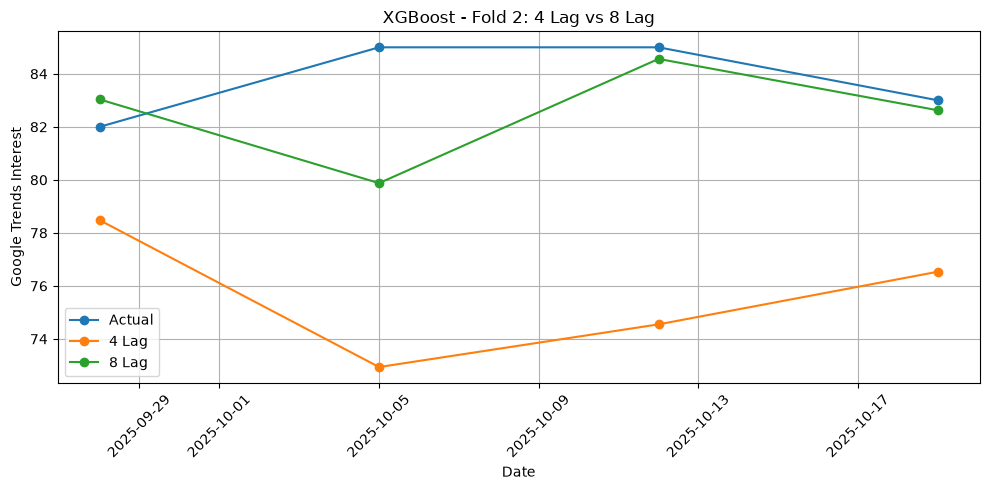

In [86]:
# grafik:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    fold_2_comparison.index,
    fold_2_comparison["actual"],
    marker="o",
    label="Actual",
)

plt.plot(
    fold_2_comparison.index,
    fold_2_comparison["predicted_4lag"],
    marker="o",
    label="4 Lag",
)

plt.plot(
    fold_2_comparison.index,
    fold_2_comparison["predicted_8lag"],
    marker="o",
    label="8 Lag",
)

plt.title("XGBoost - Fold 2: 4 Lag vs 8 Lag")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Şimdi **sadece Fold 2’nin neden 8 lag ile bu kadar düzeldiğini** okuyalım. Grafikte çok güzel görünüyor.

Fold 2’nin sınav dönemi:

```text
2025-09-28 → 82
2025-10-05 → 85
2025-10-12 → 85
2025-10-19 → 83
```

Yani gerçek seri bu 4 hafta boyunca aslında oldukça yüksek ve stabil:

```text
82 → 85 → 85 → 83
```

Şimdi Fold 2 başlamadan hemen önce modelin bildiği gerçek değerlere bakalım.

**4-lag modelin gördüğü son 4 hafta:**

```text
79 → 85 → 91 → 79
```

Modelin önüne feature olarak ters sırayla:

```text
lag_1 = 79   ← geçen hafta
lag_2 = 91
lag_3 = 85
lag_4 = 79
```

geliyor.

Bu görüntü biraz garip:

```text
79 → 85 → 91 → 79
          ↑     ↓
        tepe   sert düşüş
```

Yani yalnızca son 4 haftaya bakarsan, `91`den `79`a sert bir düşüş olmuş.

4-lag XGBoost ilk olarak yaklaşık:

```text
78.5
```

tahmin ediyor.

Gerçek:

```text
82
```

Çok korkunç değil; yaklaşık 3.5 puan hata.

**Ama kritik olay bundan sonra başlıyor.**

2. haftayı tahmin ederken gerçek `82`yi bilmiyoruz. Dolayısıyla model kendi tahmini olan `78.5`i kullanıyor:

```text
Yeni lag_1 = 78.5  ← tahmin
lag_2 = 79
lag_3 = 91
lag_4 = 85
```

Ve buradan model yaklaşık:

```text
72.9
```

tahmin ediyor.

Gerçek ise:

```text
85
```

😬

Yani ilk hata çok büyük değildi ama **recursive sistem modelin yönünü aşağı doğru çekti**:

```text
4 lag tahminleri:

78.5
 ↓
72.9
 ↑ biraz
74.5
 ↑
76.5
```

Gerçekler ise:

```text
82
↑
85
→
85
↓
83
```

İşte 4-lag modelin MAE’sinin `8.12`ye çıkmasının büyük sebebi bu.

---

Şimdi 8 lag’e bakalım.

8-lag model Fold 2 başlamadan önce sadece:

```text
79 → 85 → 91 → 79
```

görmüyor.

Daha geriye gidip yaklaşık şu **8 haftalık hikâyeyi** görüyor:

```text
77 → 72 → 75 → 79 → 79 → 85 → 91 → 79
```

Bu çok daha fazla bağlam.

4-lag model açısından görüntü:

```text
79 → 85 → 91 → 79
```

ve insan gözüyle bile:

> “Yükseldi ve sert düştü.”

diye yorumlanabilir.

Ama 8 haftalık görüntü:

```text
77 → 72 → 75 → 79 → 79 → 85 → 91 → 79
```

olunca daha geniş resimde değerlerin artık **70’lerin başından daha yüksek bir seviyeye taşındığı** görülebiliyor.

8-lag XGBoost ilk tahminde:

```text
83
```

diyor.

Gerçek:

```text
82
```

Yani sadece **1 puan civarı hata**.

Ve burada recursive forecasting bizim aleyhimize değil, lehimize çalışmaya başlıyor.

Çünkü ikinci haftaya geçerken modele verdiğimiz tahmin:

```text
83
```

gerçek değer `82`ye zaten çok yakın.

Dolayısıyla sonraki lag’ler de çok bozulmuyor.

Bu yüzden 8-lag tahminleri:

```text
83.0
79.9
84.5
82.6
```

iken gerçek:

```text
82
85
85
83
```

oluyor.

Özellikle son iki hafta neredeyse üst üste.

### Şimdilik çıkardığımız sonuç

Fold 2 bize güzel bir örnek gösteriyor:

> **4 haftalık geçmiş, son haftadaki 91 → 79 düşüşüne fazla odaklanan bir görüntü bırakmış olabilir. 8 haftalık geçmiş ise modelin daha geniş dönemde serinin yüksek bir seviyeye geçtiğini anlamasına yardımcı olmuş olabilir.**

Burada “kesin sebep budur” demiyoruz; çünkü XGBoost’un ağaçlarını tek tek incelemeden hangi eşiklerin bu sonucu doğurduğunu bilemeyiz. Ama elimizdeki veriye göre **çok makul bir açıklama**.

Ve daha da önemlisi:

> 8-lag model ilk tahmini doğruya yakın yaptığı için recursive tahminlerin geri kalanı da fazla bozulmamış.

 
 
 🔴**Fold 12’de tam tersine neden 8 lag zarar vermiş olabilir?** kısmına geçelim. 


In [87]:
fold_number = 12

train_index, test_index = list(
    tscv_aligned.split(X_8)
)[fold_number - 1]

y_train = y_8.iloc[train_index]
y_test = y_8.iloc[test_index]

print("Train:")
print(y_train.index[0], "→", y_train.index[-1])

print("\nTest:")
print(y_test.index[0], "→", y_test.index[-1])

print("\nSon 8 gerçek değer:")
print(y_train.tail(8))

Train:
2023-09-24 00:00:00 → 2026-06-28 00:00:00

Test:
2026-07-05 00:00:00 → 2026-07-26 00:00:00

Son 8 gerçek değer:
date
2026-05-10    72
2026-05-17    73
2026-05-24    70
2026-05-31    74
2026-06-07    71
2026-06-14    70
2026-06-21    68
2026-06-28    65
Name: target, dtype: int64


In [88]:
# Şimdi 4-lag modeli:

X_train_4 = X_4_aligned.iloc[train_index]

model_4 = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)

model_4.fit(X_train_4, y_train)

history_4 = list(y_train.iloc[-4:])
predictions_4 = []

for _ in range(4):
    features = [
        history_4[-lag]
        for lag in range(1, 5)
    ]

    current_features = pd.DataFrame(
        [features],
        columns=X_4_aligned.columns,
    )

    prediction = model_4.predict(current_features)[0]

    predictions_4.append(prediction)
    history_4.append(prediction)

In [89]:
#8-lag modeli:

X_train_8 = X_8.iloc[train_index]

model_8 = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
)

model_8.fit(X_train_8, y_train)

history_8 = list(y_train.iloc[-8:])
predictions_8 = []

for _ in range(4):
    features = [
        history_8[-lag]
        for lag in range(1, 9)
    ]

    current_features = pd.DataFrame(
        [features],
        columns=X_8.columns,
    )

    prediction = model_8.predict(current_features)[0]

    predictions_8.append(prediction)
    history_8.append(prediction)

In [90]:
#Sonra yan yana:

fold_12_comparison = pd.DataFrame(
    {
        "actual": y_test.values,
        "predicted_4lag": predictions_4,
        "predicted_8lag": predictions_8,
    },
    index=y_test.index,
)

fold_12_comparison

,actual,predicted_4lag,predicted_8lag
date,,,
2026-07-05,65,66.063614,69.621407
2026-07-12,65,68.682877,71.892159
2026-07-19,69,69.226318,71.619659
2026-07-26,66,70.896820,71.305763


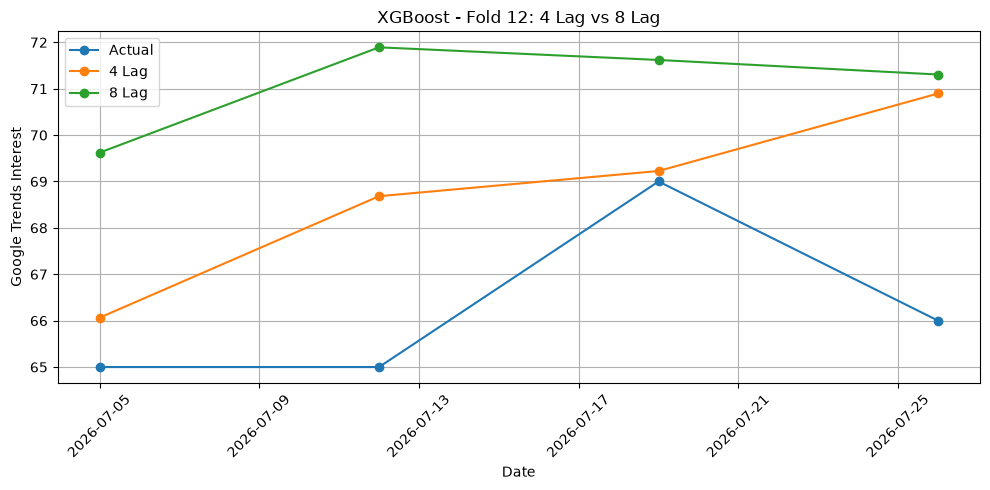

In [91]:
#Ve grafiği:

plt.figure(figsize=(10, 5))

plt.plot(
    fold_12_comparison.index,
    fold_12_comparison["actual"],
    marker="o",
    label="Actual",
)

plt.plot(
    fold_12_comparison.index,
    fold_12_comparison["predicted_4lag"],
    marker="o",
    label="4 Lag",
)

plt.plot(
    fold_12_comparison.index,
    fold_12_comparison["predicted_8lag"],
    marker="o",
    label="8 Lag",
)

plt.title("XGBoost - Fold 12: 4 Lag vs 8 Lag")
plt.xlabel("Date")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Şimdi **Fold 12’yi çok yavaş okuyalım**. Önce sadece modelin sınava girerken ne gördüğünü anlayalım; neden 8 lag’in kötüleştiğine ikinci adımda bağlayacağım.

Fold 12’de modelin eğitim verisi **28 Haziran 2026’da bitiyor**. Sonra şu dört haftayı tahmin ediyor:

```text
05 Temmuz → 65
12 Temmuz → 65
19 Temmuz → 69
26 Temmuz → 66
```

Yani bunlar sınavın cevapları. Model eğitim sırasında bunları bilmiyor.

Şimdi sınavdan önceki gerçek 8 haftaya bakalım:

```text
10 Mayıs → 72
17 Mayıs → 73
24 Mayıs → 70
31 Mayıs → 74
07 Haziran → 71
14 Haziran → 70
21 Haziran → 68
28 Haziran → 65
```

Bunu zaman çizgisi olarak yazarsak:

```text
72 → 73 → 70 → 74 → 71 → 70 → 68 → 65
```

Burada özellikle **son dört hafta** çok temiz bir düşüş gösteriyor:

```text
71 → 70 → 68 → 65
```

### 4-lag model ne görüyor?

Sadece son dört haftayı:

```text
71 → 70 → 68 → 65
```

XGBoost’a feature olarak giren hali:

```text
lag_1 = 65
lag_2 = 68
lag_3 = 70
lag_4 = 71
```

Yani modele çok net bir yakın dönem resmi veriyoruz:

> “Son haftalarda değerler 71’den 65’e doğru düşmüş.”

Ve ilk tahmini:

```text
66.06
```

Gerçek:

```text
65
```

Bu çok yakın. Daha ilk adımda yalnızca yaklaşık **1.06 puan** hata yapıyor.

---

### 8-lag model ne görüyor?

O ise aynı son dört haftanın yanında daha eski dört haftayı da görüyor:

```text
72 → 73 → 70 → 74 → 71 → 70 → 68 → 65
```

Dolayısıyla feature’ları:

```text
lag_1 = 65
lag_2 = 68
lag_3 = 70
lag_4 = 71
lag_5 = 74
lag_6 = 70
lag_7 = 73
lag_8 = 72
```

Burada dikkat et:

Son 4 hafta:

```text
71, 70, 68, 65
```

çok net şekilde aşağı gidiyor.

Ama daha eski dört haftayı ekleyince:

```text
72, 73, 70, 74
```

gibi daha yüksek ve dalgalı değerler de modele giriyor.

8-lag model ilk tahminde:

```text
69.62
```

diyor.

Gerçek:

```text
65
```

Yani daha **ilk tahminde** yaklaşık 4.62 puan yukarıda kalıyor.

Bu bize çok önemli bir ipucu veriyor:

> Bu Fold’da yakın dönem olan son 4 hafta, geleceği tahmin etmek için daha faydalıymış. Daha eski 5–8. haftaları eklemek modele yardımcı olmak yerine onu yukarı doğru çekmiş olabilir.

Ama burada dikkat: XGBoost “ortalama aldı, o yüzden yükseldi” demiyoruz. Ağaçların hangi eşikleri kullandığını incelemeden bunu kesin söyleyemeyiz. Sadece **daha eski yüksek değerlerin eklenmesiyle tahminin belirgin şekilde yükseldiğini gözlemliyoruz.**

Bir de çok güzel bir nokta var: **Fold 12 en çok eğitim verisine sahip fold.** Dolayısıyla burada 8-lag’in kötüleşmesini “model az veri gördü” diye açıklayamayız. İki model de aynı tarih aralığında eğitildi; tek esas fark 4 veya 8 lag görmeleri.

Buraya kadar otursun:

> **Fold 12’de son 4 hafta çok güncel ve güçlü bir düşüş sinyali taşıyordu. 4-lag model bu yakın döneme odaklanıp ilk tahmini 66.06 yaptı. 8-lag model daha eski, yüksek değerleri de gördü ve ilk tahmini 69.62’ye çıktı.**




## **neden 8-lag’in ilk hatası recursive tahminde 69.6 → 71.9 → 71.6 → 71.3 şeklinde devam etti?

**Evet. Şimdi sadece **recursive kısmı** anlatalım: 8-lag model ilk haftada biraz yüksek tahmin yaptıktan sonra bu hata neden devam etti?

Başlangıçta 8-lag modelin gördüğü gerçek geçmiş şuydu:

```text
72 → 73 → 70 → 74 → 71 → 70 → 68 → 65
```

İlk tahminde model dedi ki:

```text
05 Temmuz tahmini = 69.62
```

Ama gerçek değer:

```text
05 Temmuz gerçek = 65
```

Yani model yaklaşık **4.6 puan fazla tahmin yaptı**.

Buraya kadar recursive etkisi yoktu; ilk tahmin tamamen gerçek geçmişten üretildi.

Şimdi ikinci haftaya geçiyoruz: **12 Temmuz’u tahmin edeceğiz.**

Gerçek hayatta 28 Haziran’da durduğumuzu düşün. Önümüzdeki 4 haftayı birden tahmin ediyoruz. Dolayısıyla 05 Temmuz’un gerçek değerinin `65` olduğunu henüz bilmiyoruz.

Modelin elinde sadece kendi tahmini var:

```text
69.62
```

Bu yüzden eski lag’leri bir hafta kaydırıyoruz.

İlk tahmin öncesinde:

```text
lag_1 = 65
lag_2 = 68
lag_3 = 70
lag_4 = 71
lag_5 = 74
lag_6 = 70
lag_7 = 73
lag_8 = 72
```

vardı.

İkinci tahminde artık:

```text
lag_1 = 69.62  ← kendi tahmini
lag_2 = 65     ← gerçek
lag_3 = 68
lag_4 = 70
lag_5 = 71
lag_6 = 74
lag_7 = 70
lag_8 = 73
```

oluyor.

Burada ne değişti?

En güncel değer aslında gerçek dünyada:

```text
65
```

olmalıydı.

Ama model kendi dünyasında:

```text
69.62
```

görüyor.

Yani modelin kafasında seri gerçekte olduğundan **daha yüksek seviyede** devam ediyor.

Bu girdilerle ikinci tahmin:

```text
71.89
```

çıkıyor.

Gerçek ise yine:

```text
65
```

Bu sefer hata daha da büyüdü.

Şimdi üçüncü haftaya geçelim.

Model artık iki tane kendi tahminini geçmiş olarak kullanıyor:

```text
lag_1 = 71.89  ← tahmin
lag_2 = 69.62  ← tahmin
lag_3 = 65     ← gerçek
lag_4 = 68
lag_5 = 70
lag_6 = 71
lag_7 = 74
lag_8 = 70
```

Dikkat et: modelin en önemli, en güncel iki girdisi artık:

```text
69.62 → 71.89
```

Yani gerçek seri:

```text
65 → 65
```

diye giderken model kendi oluşturduğu geçmişte:

```text
69.62 → 71.89
```

diye daha yüksek bir dünya oluşturmuş durumda.

Bunun üzerine üçüncü tahmin:

```text
71.62
```

geliyor.

Gerçek değer bu sefer:

```text
69
```

Hata biraz küçülüyor ama model hâlâ yukarıda.

Son haftada ise artık son üç lag’in büyük kısmı tahminlerden oluşuyor:

```text
lag_1 = 71.62  ← tahmin
lag_2 = 71.89  ← tahmin
lag_3 = 69.62  ← tahmin
lag_4 = 65     ← gerçek
...
```

Ve model:

```text
71.31
```

tahmin ediyor.

Gerçek:

```text
66
```

### Yani zincir şöyle oldu

Gerçek gelecek:

```text
65 → 65 → 69 → 66
```

Ama model ilk hatadan sonra kendi içinde şöyle bir geçmiş üretmeye başladı:

```text
69.62 → 71.89 → 71.62 → 71.31
```

İşte recursive forecasting’in riski tam burada:

> **Bir tahmin yanlışsa, o yanlış değer bir sonraki tahminde “geçmiş veri” gibi kullanılıyor.**

Sonra o ikinci tahmin de bir sonraki tahmine giriyor.

Yani:

```text
ilk hata
   ↓
yanlış lag
   ↓
yeni tahmin
   ↓
o tahmin de lag oluyor
   ↓
hata birkaç hafta boyunca taşınabiliyor
```

Fold 12’de 4-lag modelin avantajı ise ilk tahmininin çok iyi olmasıydı:

```text
İlk gerçek = 65
4-lag tahmini = 66.06
```

Sadece yaklaşık 1 puan hata.

Dolayısıyla recursive sisteme en başta verdiği yanlış bilgi çok küçüktü. 8-lag model ise ilk adımda `69.62` diyerek daha büyük bir hata soktu ve o hata sonraki haftalara taşındı.

Buradaki ana fikir şu:

> **Recursive tahminde ilk tahmin çok önemli. İlk tahmin gerçeğe yakınsa sonraki adımlar daha sağlıklı başlayabilir; ilk tahmin belirgin şekilde yanlışsa model kendi yanlış geçmişini üretmeye başlayabilir.**


O yüzden şimdi iki ayrı hedefimiz var:

* İlk haftayı daha iyi tahmin etmek
* İlk hata olsa bile sonraki haftalarda hatanın büyümesini azaltmak

Biz şu ana kadar sadece lag sayısıyla oynadık. 8 lag ortalamada daha iyi çıktı ama Fold 12’de gördük ki bazen fazla eski bilgi ilk tahmini bozabiliyor.

Bence sıradaki mantıklı deney şu: **8 lag’i koruyalım ama modele yakın dönemin yönünü açıkça anlatan feature’lar ekleyelim.** Mesela:

change_1 = lag_1 - lag_2
change_2 = lag_2 - lag_3

Fold 12 için:

lag_1 = 65
lag_2 = 68
lag_3 = 70

change_1 = 65 - 68 = -3
change_2 = 68 - 70 = -2

Bu modele açıkça:

“Son iki haftada düşüş var.”

bilgisini verir.

Bir de:

rolling_mean_4

ekleyebiliriz; son 4 haftanın ortalama seviyesini verir.

Ben olsam sırayı şöyle götürürdüm: önce 8 lag + change feature deneyelim. XGBoost parametrelerini hâlâ değiştirmeyelim. Böylece ilk tahmini iyileştiren şey feature mı, model ayarı mı anlayabiliriz.

Şimdi 8 lag’i aynen koruyoruz, XGBoost ayarlarının hiçbirine dokunmuyoruz. Sadece modele iki yeni bilgi ekleyeceğiz:

change_1 = lag_1 - lag_2   → en son haftadaki değişim
change_2 = lag_2 - lag_3   → ondan önceki haftadaki değişim

Mesela Fold 12’nin ilk tahmininde:

lag_1 = 65
lag_2 = 68
lag_3 = 70

olduğu için:

change_1 = 65 - 68 = -3
change_2 = 68 - 70 = -2

Yani XGBoost’a artık yalnızca 65, 68, 70... sayılarını değil, açıkça:

“Son değişim -3, bir önceki değişim -2; yakın zamanda düşüş var.”

bilgisini de veriyoruz.

Önce sadece veri tablosunu hazırlayalım:

In [92]:
lag_data_8_change = lag_data_8.copy()

lag_data_8_change["change_1"] = (
    lag_data_8_change["lag_1"]
    - lag_data_8_change["lag_2"]
)

lag_data_8_change["change_2"] = (
    lag_data_8_change["lag_2"]
    - lag_data_8_change["lag_3"]
)

lag_data_8_change.head()

,target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,change_1,change_2
date,,,,,,,,,,,
2023-09-24,20,18.0,18.0,16.0,16.0,15.0,14.0,14.0,13.0,0.0,2.0
2023-10-01,19,20.0,18.0,18.0,16.0,16.0,15.0,14.0,14.0,2.0,0.0
2023-10-08,20,19.0,20.0,18.0,18.0,16.0,16.0,15.0,14.0,-1.0,2.0
2023-10-15,21,20.0,19.0,20.0,18.0,18.0,16.0,16.0,15.0,1.0,-1.0
2023-10-22,20,21.0,20.0,19.0,20.0,18.0,18.0,16.0,16.0,1.0,1.0


Sonra X ve y:

In [93]:
X_8_change = lag_data_8_change[
    [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_4",
        "lag_5",
        "lag_6",
        "lag_7",
        "lag_8",
        "change_1",
        "change_2",
    ]
]

y_8_change = lag_data_8_change["target"]

print("X shape:", X_8_change.shape)
print("y shape:", y_8_change.shape)

X shape: (149, 10)
y shape: (149,)


In [94]:
def evaluate_xgb_recursive_with_change(
    X,
    y,
    splitter,
    n_lags=8,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X),
        start=1,
    ):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            random_state=42,
        )

        model.fit(X_train, y_train)

        history = list(
            y_train.iloc[-n_lags:]
        )

        predictions = []

        for _ in range(len(y_test)):
            lag_features = [
                history[-lag]
                for lag in range(1, n_lags + 1)
            ]

            change_1 = (
                lag_features[0]
                - lag_features[1]
            )

            change_2 = (
                lag_features[1]
                - lag_features[2]
            )

            features = (
                lag_features
                + [change_1, change_2]
            )

            current_features = pd.DataFrame(
                [features],
                columns=X.columns,
            )

            prediction = model.predict(
                current_features
            )[0]

            predictions.append(prediction)
            history.append(prediction)

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = root_mean_squared_error(
            y_test,
            predictions,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

In [95]:
xgb_8_change_results = evaluate_xgb_recursive_with_change(
    X_8_change,
    y_8_change,
    tscv_aligned,
    n_lags=8,
)

In [96]:
print("8 Lag:")
print(
    xgb_8_results[
        ["MAE", "RMSE"]
    ].mean()
)

print("\n8 Lag + Change:")
print(
    xgb_8_change_results[
        ["MAE", "RMSE"]
    ].mean()
)

8 Lag:
MAE     4.551718
RMSE    5.136372
dtype: float64

8 Lag + Change:
MAE     4.535622
RMSE    5.073984
dtype: float64


Evet, senin yorumun doğru: **genel ortalamada fark çok küçük.**

```text
8 Lag
MAE  = 4.5517
RMSE = 5.1364

8 Lag + Change
MAE  = 4.5356
RMSE = 5.0740
```

Yani `change_1` ve `change_2` ekleyince:

* MAE sadece yaklaşık **0.016** düştü → yaklaşık **%0.35 iyileşme**
* RMSE yaklaşık **0.062** düştü → yaklaşık **%1.2 iyileşme**

Bu yüzden şu an:

> **“Change feature eklemek modeli belirgin şekilde iyileştirdi.”**

diyemeyiz. Daha doğru yorum:

> **“Küçük bir iyileşme sağladı ama etkisi sınırlı kaldı.”**

Bunun mantıklı bir sebebi de var. Mesela:

```text
lag_1 = 65
lag_2 = 68
```

zaten XGBoost'un elinde. Biz ayrıca:

```text
change_1 = 65 - 68 = -3
```

verdik.

Bu yeni sütun bilgiyi daha açık hale getiriyor ama aslında **tamamen yeni bir bilgi değil**; `lag_1` ve `lag_2`den türetilmiş bir bilgi. XGBoost ağaçları zaten bu iki lag arasındaki kombinasyonlardan bazı ilişkileri öğrenebiliyor. O yüzden mucizevi bir fark çıkmaması normal.

Ama henüz `change` işe yaramadı diye atmayalım. Özellikle merak ettiğimiz şey şu:

> **Fold 12'de ilk tahmini iyileştirdi mi?**

Çünkü change feature'ı ekleme fikrimizin çıkış noktası Fold 12'deki düşüşü modele daha açık anlatmaktı.

Şimdi sadece fold bazında karşılaştıralım:



Özellikle **Fold 12 satırına** bakacağız. Eğer Fold 12 ciddi düzelmiş ama başka foldlar kötüleşmişse, “change faydasız” değil, **bazı piyasa/trend durumlarında faydalı ama genelde yeterli değil** diyeceğiz.


In [97]:

change_comparison = xgb_8_results.merge(
    xgb_8_change_results,
    on="fold",
    suffixes=("_8lag", "_change"),
)

change_comparison["MAE_improvement"] = (
    change_comparison["MAE_8lag"]
    - change_comparison["MAE_change"]
)

change_comparison[
    [
        "fold",
        "MAE_8lag",
        "MAE_change",
        "MAE_improvement",
    ]
]


,fold,MAE_8lag,MAE_change,MAE_improvement
0,1,10.771460,10.188013,0.583447
1,2,1.743414,2.564495,-0.821081
2,3,1.156664,0.982641,0.174023
3,4,8.267813,8.473801,-0.205988
4,5,11.811993,12.031218,-0.219225
5,6,1.770987,1.648991,0.121996
6,7,4.775108,4.956863,-0.181755
7,8,3.273706,2.926397,0.347309
8,9,1.185846,1.054356,0.131491
9,10,1.142384,1.253756,-0.111372


Evet, yorumun doğru. Fold 12’de **bir miktar iyileşme var ama güçlü değil**.

```text
8 lag:
MAE = 4.86

8 lag + change:
MAE = 4.40

İyileşme ≈ 0.46
```

Yani change feature’lar Fold 12’de işe yaramış, ama problemi çözmemiş. Model hâlâ o dönemde belirgin hata yapıyor.

Daha genel tabloya bakınca da durum şu: bazı foldlarda change feature fayda sağlamış, bazılarında zarar vermiş. Mesela Fold 1’de yaklaşık `+0.58` iyileşme var ama Fold 2’de `-0.82` kötüleşme var. Bu yüzden ortalamada etkisi çok küçük kalıyor.

Buradan çıkaracağımız daha sağlam sonuç:

> `change_1` ve `change_2`, yakın dönem yönünü modele daha açık verdi ama bu bilgi tek başına XGBoost performansını belirgin şekilde iyileştirmedi.

Yani şu aşamada **change feature’ı ana çözümümüz değil**.

Bence şimdi bir sonraki mantıklı deney **rolling mean** olabilir. Çünkü 8 lag model bazen eski yüksek değerlere fazla takılıyor gibi göründü. Son 4 haftanın ortalamasını ayrıca verirsek modele “yakın dönemin genel seviyesi” hakkında tek bir özet bilgi sunmuş oluruz.

Örneğin Fold 12’de:

```text
son 4 hafta:
71, 70, 68, 65

rolling_mean_4 = 68.5
```

Bu, modele “yakın dönemin seviyesi artık 68–69 civarında” mesajını daha açık verir.

İstersen sıradaki kontrollü deneyimiz **8 lag + rolling_mean_4** olsun; change feature’ı şimdilik eklemeyelim ki etkisini ayrı ölçelim.


## Rolling Mean Nedir?

Rolling mean = **kayan ortalama**.

Mesela Fold 12’de son 4 gerçek değerimiz:

```text
71 → 70 → 68 → 65
```

Son 4 haftanın ortalaması:

```text
(71 + 70 + 68 + 65) / 4 = 68.5
```

İşte buna o an için:

```text
rolling_mean_4 = 68.5
```

diyoruz.

**“Rolling/kayan”** denmesinin sebebi, bir hafta ilerlediğimizde pencerenin de ilerlemesi.

Mesela yeni değer `66` gelmiş olsun. Artık en eski `71` dışarı çıkar:

```text
Önce:
71, 70, 68, 65
ortalama = 68.5

Bir hafta sonra:
70, 68, 65, 66
ortalama = 67.25
```

Yani sürekli **son 4 değerin ortalamasını** hesaplıyoruz.

Biz bunu neden XGBoost’a vermek istiyoruz?

Şu anda model:

```text
lag_1 = 65
lag_2 = 68
lag_3 = 70
lag_4 = 71
...
```

görüyor.

`rolling_mean_4 = 68.5` eklersek ayrıca:

> “Son bir ayın genel seviyesi yaklaşık 68.5.”

bilgisini de açıkça vermiş oluyoruz.

Mesela Fold 12’de 8-lag model eski değerlerde `72, 73, 70, 74` gibi daha yüksek sayıları da görüyordu. `rolling_mean_4=68.5` ise modelin dikkatine **yakın dönemin artık daha düşük bir seviyede olduğunu** sunabilir.

Ama `change` gibi bunun da tamamen yeni bir bilgi olmadığını unutmayalım. Çünkü `68.5`, zaten `lag_1...lag_4` kullanılarak hesaplanıyor. Deneyip gerçekten faydası var mı CV ile göreceğiz.

Kısaca:

**change** → “hangi yöne gidiyoruz?”
**rolling mean** → “yakın dönemde genel olarak hangi seviyedeyiz?”

Şimdilik change’leri dahil etmeyelim. Çünkü şu an kontrollü deney yapıyoruz ve tek bir şeyi değiştirmek istiyoruz.


In [99]:
# Şimdi 8 lag’i koruyup sadece rolling_mean_4 ekleyeceğiz. XGBoost ayarlarına yine dokunmuyoruz.

# tabloya yeni feature’ı ekle:

lag_data_8_roll = lag_data_8.copy()

lag_data_8_roll["rolling_mean_4"] = (
    lag_data_8_roll[
        ["lag_1", "lag_2", "lag_3", "lag_4"]
    ].mean(axis=1)
)

lag_data_8_roll.head()

,target,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,rolling_mean_4
date,,,,,,,,,,
2023-09-24,20,18.0,18.0,16.0,16.0,15.0,14.0,14.0,13.0,17.00
2023-10-01,19,20.0,18.0,18.0,16.0,16.0,15.0,14.0,14.0,18.00
2023-10-08,20,19.0,20.0,18.0,18.0,16.0,16.0,15.0,14.0,18.75
2023-10-15,21,20.0,19.0,20.0,18.0,18.0,16.0,16.0,15.0,19.25
2023-10-22,20,21.0,20.0,19.0,20.0,18.0,18.0,16.0,16.0,20.00


Buradaki:

.mean(axis=1)

şu demek:

Her satırda lag_1, lag_2, lag_3, lag_4 değerlerini toplayıp ortalamasını al.

In [100]:
#X be Y:

X_8_roll = lag_data_8_roll[
    [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_4",
        "lag_5",
        "lag_6",
        "lag_7",
        "lag_8",
        "rolling_mean_4",
    ]
]

y_8_roll = lag_data_8_roll["target"]

print("X shape:", X_8_roll.shape)
print("y shape:", y_8_roll.shape)

X shape: (149, 9)
y shape: (149,)


In [101]:
#Şimdi 8 lag + rolling_mean_4 modelini aynı 12 fold üzerinde test edeceğiz.

# Recursive tahminde rolling mean’i her adımda yeniden hesaplamamız gerekiyor. Fonksiyon:

def evaluate_xgb_recursive_with_rolling(
    X,
    y,
    splitter,
    n_lags=8,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X),
        start=1,
    ):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=100,
            max_depth=3,
            learning_rate=0.05,
            random_state=42,
        )

        model.fit(X_train, y_train)

        history = list(
            y_train.iloc[-n_lags:]
        )

        predictions = []

        for _ in range(len(y_test)):
            lag_features = [
                history[-lag]
                for lag in range(1, n_lags + 1)
            ]

            rolling_mean_4 = sum(
                lag_features[:4]
            ) / 4

            features = (
                lag_features
                + [rolling_mean_4]
            )

            current_features = pd.DataFrame(
                [features],
                columns=X.columns,
            )

            prediction = model.predict(
                current_features
            )[0]

            predictions.append(prediction)
            history.append(prediction)

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = root_mean_squared_error(
            y_test,
            predictions,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

In [102]:
xgb_8_roll_results = evaluate_xgb_recursive_with_rolling(
    X_8_roll,
    y_8_roll,
    tscv_aligned,
    n_lags=8,
)

In [103]:
# 3 model yan yana

print("8 Lag:")
print(
    xgb_8_results[
        ["MAE", "RMSE"]
    ].mean()
)

print("\n8 Lag + Change:")
print(
    xgb_8_change_results[
        ["MAE", "RMSE"]
    ].mean()
)

print("\n8 Lag + Rolling Mean:")
print(
    xgb_8_roll_results[
        ["MAE", "RMSE"]
    ].mean()
)

8 Lag:
MAE     4.551718
RMSE    5.136372
dtype: float64

8 Lag + Change:
MAE     4.535622
RMSE    5.073984
dtype: float64

8 Lag + Rolling Mean:
MAE     4.577720
RMSE    5.091935
dtype: float64


Evet, sonuç çok net: **rolling mean tek başına fayda sağlamadı**, hatta MAE’yi biraz kötüleştirdi.

```text
8 Lag
MAE  = 4.5517
RMSE = 5.1364

8 Lag + Change
MAE  = 4.5356
RMSE = 5.0740

8 Lag + Rolling Mean
MAE  = 4.5777
RMSE = 5.0919
```

Yani şu ana kadarki sıralama:

```text
En iyi MAE  → 8 Lag + Change
En iyi RMSE → 8 Lag + Change
```

Ama farklar çok küçük. Bu yüzden `change` için de “büyük iyileşme” demiyoruz; sadece **en azından biraz katkı sağladı** diyoruz.

Rolling mean neden çok işe yaramamış olabilir? Çünkü:

```text
rolling_mean_4
```

aslında zaten:

```text
lag_1
lag_2
lag_3
lag_4
```

içinden hesaplanıyor. Yani modele tamamen yeni bir bilgi vermiyoruz, sadece mevcut dört sayıyı tek bir özet sayıya çeviriyoruz.

Bu deneyden çıkaracağımız sonuç bence şu:

> **XGBoost için asıl büyük iyileşme 4 lag’den 8 lag’e geçince geldi. Change ve rolling mean gibi ek feature’ların etkisi ise oldukça sınırlı kaldı.**

Bu önemli, çünkü artık feature tarafında neyin gerçekten etkili olduğunu biraz ayırabildik.

Şimdi bence bir sonraki en mantıklı adım **XGBoost’un kendi parametrelerini** kontrollü şekilde denemek. Mesela önce yalnızca `max_depth`:

```text
2
3  ← şu anki
4
5
```

değerlerini aynı **8 Lag + Change** yapı üzerinde test edelim. Böylece “ağaç biraz daha derin olsa daha iyi öğreniyor mu?” sorusuna bakarız.


## Max_depth değiştirme

Devam. Şimdi sadece max_depth değerini değiştireceğiz. Diğer her şeyi sabit tutacağız:

8 lag + change
n_estimators = 100
learning_rate = 0.05

Sadece:

max_depth = 2, 3, 4, 5

deneyeceğiz.

Hatırlatma: max_depth, her bir karar ağacının kaç seviye derine inebileceğini, yani ne kadar ayrıntılı kurallar öğrenebileceğini belirliyor. XGBoost dokümantasyonunda da ağacın maksimum derinliği olarak tanımlanıyor.

Mesela:

depth = 2
lag_1 > 70?
   ↓
lag_2 > 65?
   ↓
tahmin

daha basit.

depth = 5 olunca:

lag_1 > 70?
 ↓
lag_2 > 65?
 ↓
change_1 > 0?
 ↓
lag_6 > 60?
 ↓
...

gibi daha ayrıntılı kurallar öğrenebilir.

In [104]:
# Önce mevcut fonksiyonumuzu max_depth alacak hale getirelim:

def evaluate_xgb_recursive_with_change(
    X,
    y,
    splitter,
    n_lags=8,
    max_depth=3,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X),
        start=1,
    ):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=100,
            max_depth=max_depth,
            learning_rate=0.05,
            random_state=42,
        )

        model.fit(X_train, y_train)

        history = list(
            y_train.iloc[-n_lags:]
        )

        predictions = []

        for _ in range(len(y_test)):
            lag_features = [
                history[-lag]
                for lag in range(1, n_lags + 1)
            ]

            change_1 = (
                lag_features[0]
                - lag_features[1]
            )

            change_2 = (
                lag_features[1]
                - lag_features[2]
            )

            features = (
                lag_features
                + [change_1, change_2]
            )

            current_features = pd.DataFrame(
                [features],
                columns=X.columns,
            )

            prediction = model.predict(
                current_features
            )[0]

            predictions.append(prediction)
            history.append(prediction)

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = root_mean_squared_error(
            y_test,
            predictions,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

“Aynı veri ve aynı feature’larla, ağaçların daha basit veya daha karmaşık olması XGBoost’u iyileştiriyor mu?”

In [ ]:
# Şimdi dört değeri deneyelim:
depth_results = []

for depth in [2, 3, 4, 5]:
    result = evaluate_xgb_recursive_with_change(
        X_8_change,
        y_8_change,
        tscv_aligned,
        n_lags=8,
        max_depth=depth,
    )

    depth_results.append(
        {
            "max_depth": depth,
            "MAE": result["MAE"].mean(),
            "RMSE": result["RMSE"].mean(),
        }
    )

depth_results_df = pd.DataFrame(
    depth_results
)

depth_results_df.sort_values("MAE")

,max_depth,MAE,RMSE
0,2,4.471861,5.013324
1,3,4.535622,5.073984
2,4,5.467226,6.015672
3,5,5.619951,6.203780


Bu sonuç bayağı öğretici. **Daha derin ağaç daha iyi olmadı; tam tersine kötüleşti.**

Sonuç:

| max_depth |       MAE |      RMSE |
| --------: | --------: | --------: |
|     **2** | **4.471** | **5.013** |
|         3 |     4.536 |     5.074 |
|         4 |     5.467 |     6.016 |
|         5 |     5.620 |     6.204 |

Yani şu an en iyi `max_depth=2`.

Bunu basitçe şöyle yorumlayabiliriz:

`depth=2` daha basit kurallar kuruyor. Mesela:

```text
lag_1 > 70 mi?
  ↓
change_1 > 0 mı?
```

gibi.

`depth=4` veya `5` olduğunda ağaç çok daha detaylı ayrımlar yapabiliyor. Bu da bizim veri setimiz gibi görece küçük bir veride, bazı eski örneklere fazla özel kurallar öğrenmesine yol açmış olabilir.

Yani kabaca:

```text
depth 2 → daha sade, daha genellenebilir
depth 3 → hâlâ iyi
depth 4-5 → fazla ayrıntıya kaçmış olabilir
```

Bu da “daha karmaşık model = daha iyi model” olmadığını güzel gösteriyor.

Şu anda XGBoost için en iyi kombinasyonumuz:

```text
8 lag
+ change_1
+ change_2
+ max_depth = 2
```

ve sonuç:

```text
MAE  ≈ 4.47
RMSE ≈ 5.01
```

Bu hâlâ Prophet’in yaklaşık `4.30 / 4.83` sonucunun biraz gerisinde, ama artık ilk XGBoost halimizden (`MAE ≈ 5.22`) ciddi şekilde daha iyi.

Bence sıradaki kontrollü parametre **`n_estimators`** olsun. `max_depth=2`yi sabit tutup:

```text
50
100
200
300
```

ağaç deneyebiliriz. Böylece “daha fazla boosting turu gerçekten işe yarıyor mu?” bakarız.


## n_estimators değiştirme

Devam. Şimdi n_estimators, yani kaç boosting ağacı kullanılacağını test edeceğiz. XGBoost’un güncel dokümantasyonunda da n_estimators, gradient-boosted tree / boosting round sayısı olarak tanımlanıyor.

Şu an en iyi yapımızı sabit tutuyoruz:

8 lag + change
max_depth = 2
learning_rate = 0.05

Sadece şunu değiştiriyoruz:

n_estimators = 50, 100, 200, 300

Önce fonksiyona n_estimators parametresini ekleyelim:

In [106]:
def evaluate_xgb_recursive_with_change(
    X,
    y,
    splitter,
    n_lags=8,
    max_depth=2,
    n_estimators=100,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X),
        start=1,
    ):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=0.05,
            random_state=42,
        )

        model.fit(X_train, y_train)

        history = list(
            y_train.iloc[-n_lags:]
        )

        predictions = []

        for _ in range(len(y_test)):
            lag_features = [
                history[-lag]
                for lag in range(1, n_lags + 1)
            ]

            change_1 = (
                lag_features[0]
                - lag_features[1]
            )

            change_2 = (
                lag_features[1]
                - lag_features[2]
            )

            features = (
                lag_features
                + [change_1, change_2]
            )

            current_features = pd.DataFrame(
                [features],
                columns=X.columns,
            )

            prediction = model.predict(
                current_features
            )[0]

            predictions.append(prediction)
            history.append(prediction)

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = root_mean_squared_error(
            y_test,
            predictions,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

Şimdi deney:

Mantık şu:

50 ağaç
→ daha az düzeltme turu

100 ağaç
→ şu anki model

200 / 300 ağaç
→ daha fazla düzeltme turu

Ama yine “daha fazla ağaç = daha iyi” diye düşünmüyoruz. Çünkü model bir noktadan sonra eğitim örneklerinin ayrıntılarına fazla uyabilir. learning_rate=0.05i sabit tuttuğumuz için burada gerçekten ağaç sayısının etkisini ölçüyoruz.

Tabloyu gönder; sonra sonucu birlikte yorumlayalım.

In [107]:
estimator_results = []

for n_estimators in [50, 100, 200, 300]:
    result = evaluate_xgb_recursive_with_change(
        X_8_change,
        y_8_change,
        tscv_aligned,
        n_lags=8,
        max_depth=2,
        n_estimators=n_estimators,
    )

    estimator_results.append(
        {
            "n_estimators": n_estimators,
            "MAE": result["MAE"].mean(),
            "RMSE": result["RMSE"].mean(),
        }
    )

estimator_results_df = pd.DataFrame(
    estimator_results
)

estimator_results_df.sort_values("MAE")

,n_estimators,MAE,RMSE
2,200,4.401295,4.922008
3,300,4.430038,4.964070
1,100,4.471861,5.013324
0,50,5.647415,6.281135


Evet 😄 **200 tahminimiz tuttu.** Sonuç çok güzel bir şekil göstermiş:

```text
n_estimators    MAE       RMSE

50              5.647     6.281   ❌
100             4.472     5.013
200             4.401     4.922   ✅ en iyi
300             4.430     4.964
```

Burada olan şeyi adım adım okuyalım.

`50` ağaçta model belirgin şekilde kötü. Bizim `learning_rate=0.05` değerimiz düşük olduğu için her ağaç küçük bir düzeltme yapıyor. **50 düzeltme turu yeterli gelmemiş** gibi görünüyor.

100'e çıkınca:

```text
MAE:
5.65 → 4.47
```

çok ciddi iyileşiyor.

200'e çıkınca:

```text
4.47 → 4.40
```

biraz daha iyileşiyor.

Ama 300'e çıktığımızda:

```text
4.40 → 4.43
```

yeniden hafif kötüleşiyor.

Yani burada gerçekten bahsettiğimiz **tatlı noktayı** görüyoruz:

```text
çok az ağaç             uygun bölge          daha fazla
    50       → 100 →     200      → 300
   kötü                   ⭐          hafif kötü
```

Bu bize şunu söylüyor:

> **Bu veri ve şu anki feature yapımız için 200 boosting turu yeterli görünüyor. Daha fazla ağaç eklemek ekstra fayda sağlamıyor.**

Şu anda en iyi XGBoost konfigürasyonumuz:

```python
XGBRegressor(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.05,
    random_state=42,
)
```

Feature'larımız da:

```text
lag_1 ... lag_8
change_1
change_2
```

Ve performans:

```text
MAE  = 4.401
RMSE = 4.922
```

Başlangıçta 4 lagli XGBoost yaklaşık:

```text
MAE = 5.22
RMSE = 5.83
```

idi. Yani yaptığımız iyileştirmeler gerçekten işe yaradı.

Şimdi sırada üçüncü ana parametre var: **`learning_rate`**. Şu anda `0.05`. Artık `max_depth=2` ve `n_estimators=200` değerlerini sabitleyip sadece learning rate'i değiştireceğiz. Böylece her ağacın yaptığı düzeltmenin ne kadar güçlü olması gerektiğini test edeceğiz. ama ondan önce:


## 8 lag gerçekten gerekli miydi, yoksa 4 lag modeli de iyi parametrelerle ayarlayınca aynı seviyeye geliyor mu?

Adil olması için aynı 149 haftayı, aynı change_1/change_2 feature’larını ve şu an bulduğumuz parametreleri kullanacağız:

max_depth = 2
n_estimators = 200
learning_rate = 0.05

In [108]:
#Önce 4-lag + change verisini oluşturalım:

X_4_change = X_4_aligned.copy()

X_4_change["change_1"] = (
    X_4_change["lag_1"]
    - X_4_change["lag_2"]
)

X_4_change["change_2"] = (
    X_4_change["lag_2"]
    - X_4_change["lag_3"]
)

X_4_change.head()

,lag_1,lag_2,lag_3,lag_4,change_1,change_2
date,,,,,,
2023-09-24,18.0,18.0,16.0,16.0,0.0,2.0
2023-10-01,20.0,18.0,18.0,16.0,2.0,0.0
2023-10-08,19.0,20.0,18.0,18.0,-1.0,2.0
2023-10-15,20.0,19.0,20.0,18.0,1.0,-1.0
2023-10-22,21.0,20.0,19.0,20.0,1.0,1.0


In [109]:
print(X_4_change.shape)
print(X_8_change.shape)

(149, 6)
(149, 10)


In [110]:
#Şimdi 4-lag modelini aynı tuned parametrelerle çalıştır:

xgb_4_tuned_results = evaluate_xgb_recursive_with_change(
    X_4_change,
    y_4_aligned,
    tscv_aligned,
    n_lags=4,
    max_depth=2,
    n_estimators=200,
)

In [111]:
#8-lag için de aynı parametrelerle sonucu alalım:

xgb_8_tuned_results = evaluate_xgb_recursive_with_change(
    X_8_change,
    y_8_change,
    tscv_aligned,
    n_lags=8,
    max_depth=2,
    n_estimators=200,
)

In [112]:
# karşılaştırma:

print("4 Lag + Change + Tuned:")
print(
    xgb_4_tuned_results[
        ["MAE", "RMSE"]
    ].mean()
)

print("\n8 Lag + Change + Tuned:")
print(
    xgb_8_tuned_results[
        ["MAE", "RMSE"]
    ].mean()
)

4 Lag + Change + Tuned:
MAE     5.527940
RMSE    6.073879
dtype: float64

8 Lag + Change + Tuned:
MAE     4.401295
RMSE    4.922008
dtype: float64


## Learning_rate değiştirme

Tamam, 8 lag + change yapısını ana XGBoost modelimiz kabul edip oradan devam edelim.

Şu an sabitlediklerimiz:

lag_1 ... lag_8
change_1
change_2

max_depth = 2
n_estimators = 200

Şimdi sadece learning_rate değiştireceğiz.

Mantığı hatırlarsak:

küçük learning_rate
→ her ağaç küçük düzeltme yapar

büyük learning_rate
→ her ağaç daha güçlü düzeltme yapar

Biz şu an:

learning_rate = 0.05

kullanıyoruz.

Bence şu değerleri deneyelim:

0.01
0.03
0.05
0.10
0.20

Önce fonksiyonumuza learning_rate parametresi ekle:

In [113]:
def evaluate_xgb_recursive_with_change(
    X,
    y,
    splitter,
    n_lags=8,
    max_depth=2,
    n_estimators=200,
    learning_rate=0.05,
):
    results = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X),
        start=1,
    ):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = XGBRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            random_state=42,
        )

        model.fit(X_train, y_train)

        history = list(
            y_train.iloc[-n_lags:]
        )

        predictions = []

        for _ in range(len(y_test)):
            lag_features = [
                history[-lag]
                for lag in range(1, n_lags + 1)
            ]

            change_1 = (
                lag_features[0]
                - lag_features[1]
            )

            change_2 = (
                lag_features[1]
                - lag_features[2]
            )

            features = (
                lag_features
                + [change_1, change_2]
            )

            current_features = pd.DataFrame(
                [features],
                columns=X.columns,
            )

            prediction = model.predict(
                current_features
            )[0]

            predictions.append(prediction)
            history.append(prediction)

        mae = mean_absolute_error(
            y_test,
            predictions,
        )

        rmse = root_mean_squared_error(
            y_test,
            predictions,
        )

        results.append(
            {
                "fold": fold,
                "MAE": mae,
                "RMSE": rmse,
            }
        )

    return pd.DataFrame(results)

In [114]:
# tuning

learning_rate_results = []

for rate in [0.01, 0.03, 0.05, 0.10, 0.20]:
    result = evaluate_xgb_recursive_with_change(
        X_8_change,
        y_8_change,
        tscv_aligned,
        n_lags=8,
        max_depth=2,
        n_estimators=200,
        learning_rate=rate,
    )

    learning_rate_results.append(
        {
            "learning_rate": rate,
            "MAE": result["MAE"].mean(),
            "RMSE": result["RMSE"].mean(),
        }
    )

learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_results_df.sort_values("MAE")

,learning_rate,MAE,RMSE
2,0.05,4.401295,4.922008
1,0.03,4.436868,4.973790
3,0.10,4.487576,5.028622
4,0.20,4.860270,5.365065
0,0.01,7.193860,7.694663


Burada da en iyi değer **`learning_rate = 0.05`** çıktı. Güzel tarafı şu: zaten kullandığımız değer doğru bölgedeymiş.

```text
learning_rate   MAE      RMSE
0.05            4.401    4.922   ← en iyi
0.03            4.437    4.974
0.10            4.488    5.029
0.20            4.860    5.365
0.01            7.194    7.695   ← çok kötü
```

Bunu şöyle okuyabiliriz:

`0.01` çok küçük. Her ağaç minicik düzeltme yapıyor ve **200 ağaç modelin yeterince öğrenmesine yetmemiş** gibi görünüyor.

`0.03` ve `0.05` iyi bölge. `0.05` biraz daha iyi.

`0.10`dan sonra düzeltmeler daha güçlü hale geliyor ve performans yavaş yavaş bozuluyor. `0.20` belirgin şekilde kötüleşmiş.

Yani şu anda en iyi XGBoost’umuz:

```python
XGBRegressor(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.05,
    random_state=42,
)
```

ve feature’larımız:

```text
lag_1 ... lag_8
change_1
change_2
```

Sonuç:

```text
MAE  = 4.401
RMSE = 4.922
```

Başladığımız XGBoost ise yaklaşık:

```text
4 lag
100 ağaç
depth=3

MAE  = 5.218
RMSE = 5.832
```

Yani bayağı geliştirdik.

Ama şimdi önemli bir metodoloji noktası var: **`learning_rate` ile `n_estimators` birbirine bağlı.** Mesela `0.03` değeri 200 ağaçta `0.05`ten biraz kötü çıktı ama belki:

```text
learning_rate = 0.03
n_estimators = 300
```

kombinasyonu daha iyi olabilir.

Bu yüzden ben yeni bir parametreye geçmeden önce minicik bir final grid yapardım:

```text
learning_rate: 0.03, 0.05, 0.10
n_estimators: 100, 200, 300
```

`max_depth=2` sabit. Böylece bu iki parametrenin **birlikte en iyi kombinasyonunu** buluruz. Ondan sonra XGBoost tuning'i kapatabiliriz.


## max_depth=2 sabit; sadece learning_rate ve n_estimators kombinasyonlarını deniyoruz.

In [115]:
grid_results = []

for rate in [0.03, 0.05, 0.10]:
    for estimators in [100, 200, 300]:

        result = evaluate_xgb_recursive_with_change(
            X_8_change,
            y_8_change,
            tscv_aligned,
            n_lags=8,
            max_depth=2,
            n_estimators=estimators,
            learning_rate=rate,
        )

        grid_results.append(
            {
                "learning_rate": rate,
                "n_estimators": estimators,
                "MAE": result["MAE"].mean(),
                "RMSE": result["RMSE"].mean(),
            }
        )

Burada toplam:

3 learning rate
×
3 estimator sayısı
=
9 farklı model

denemiş olacağız.

In [116]:
grid_results_df = pd.DataFrame(
    grid_results
)

grid_results_df.sort_values(
    "MAE"
).reset_index(drop=True)

,learning_rate,n_estimators,MAE,RMSE
0,0.03,300,4.355784,4.901813
1,0.10,100,4.373560,4.918064
2,0.05,200,4.401295,4.922008
3,0.05,300,4.430038,4.964070
4,0.03,200,4.436868,4.973790
5,0.05,100,4.471861,5.013324
6,0.10,200,4.487576,5.028622
7,0.10,300,4.560353,5.128901
8,0.03,100,5.195333,5.799723


### XGBoost Model Tuning Sonucu

XGBoost modeli için önce 4 lag ile başlangıç modeli oluşturuldu. Daha sonra modelin daha uzun geçmişten faydalanıp faydalanmadığını görmek amacıyla 8 lag kullanıldı ve 8 lag yapısının 4 lag yapısına göre daha iyi performans verdiği görüldü.

Ek feature olarak `change_1` ve `change_2` değerleri eklenerek yakın dönem yön değişimleri modele açık şekilde verildi. Rolling mean feature'ı da test edildi ancak belirgin bir iyileşme sağlamadı.

Daha sonra XGBoost hyperparameter tuning yapıldı. Kontrollü deneylerle `max_depth`, `n_estimators` ve `learning_rate` değerleri karşılaştırıldı.

En iyi bulunan yapı:

- 8 lag
- `change_1`
- `change_2`
- `max_depth = 2`
- `n_estimators = 300`
- `learning_rate = 0.03`

12 fold ve 4 haftalık recursive time-series cross-validation sonucunda:

- MAE ≈ 4.356
- RMSE ≈ 4.902

Başlangıç XGBoost modeline göre hata değerlerinde belirgin bir iyileşme sağlandı. Bir sonraki aşamada tuned XGBoost modeli Naive, ARIMA ve Prophet modelleriyle aynı değerlendirme yapısı altında karşılaştırılacaktır.

In [ ]:
best_xgb_params = {
    "n_estimators": 300,
    "max_depth": 2,
    "learning_rate": 0.03,
    "random_state": 42,
}

best_xgb_params

# Diğer Modellerle Karşılaştırma

Aynı yaklaşık 30 günlük tahmin hedefi için kullanılan 12 fold ve 4 haftalık
time-series cross-validation sonuçları karşılaştırıldığında modellerin
performansları birbirine oldukça yakın bulunmuştur.

| Model | MAE | RMSE |
| --- | ---: | ---: |
| Prophet (`cps=1.0`) | 4.303 | 4.826 |
| Tuned XGBoost | 4.356 | 4.902 |
| ARIMA(1,1,1) | 4.409 | 4.998 |
| Naive | 4.542 | 5.241 |

Prophet (`cps=1.0`) mevcut değerlendirmede en düşük MAE ve RMSE değerlerini
vererek ilk sırada yer almıştır. Tuned XGBoost modeli ise Prophet'e oldukça
yakın sonuçlar elde etmiş ve ARIMA ile Naive modellerinden daha düşük hata
değerlerine ulaşmıştır.

XGBoost'un başlangıç modelinde MAE yaklaşık 5.22 ve RMSE yaklaşık 5.83 iken;
lag sayısının artırılması, değişim feature'larının eklenmesi ve
hyperparameter tuning sonucunda MAE yaklaşık 4.36, RMSE ise 4.90 seviyesine
düşürülmüştür.

Bu sonuçlar, model seçiminin yalnızca tek bir test dönemine göre değil,
farklı zaman dönemlerini kapsayan cross-validation sonuçlarına göre yapılmasının
önemini göstermektedir. Şu aşamada Prophet en iyi aday olarak görünse de
XGBoost'un performansı oldukça yakındır. Sonraki aşamada aynı değerlendirme
yaklaşımının Gemini ve Claude serilerine uygulanarak model performanslarının
farklı trend serilerinde nasıl değiştiği incelenecektir.

> **Metodoloji Notu:** XGBoost modeli, 8 lag kullanımı nedeniyle ilk 8 haftanın
> feature oluşturmak için kullanılamaması sonucunda 149 satırlık hizalanmış veri
> üzerinden değerlendirilmiştir. Prophet, ARIMA ve Naive modellerinin önceki
> cross-validation sonuçları ise biraz daha uzun başlangıç geçmişi kullanılarak
> elde edilmiştir. Bu nedenle yukarıdaki tablo aynı 12 fold × 4 haftalık
> değerlendirme yaklaşımını karşılaştırmakla birlikte, modellerin eğitim başlangıç
> tarihleri tamamen birebir değildir.
>
> Final model karşılaştırması yapılırken tüm modellerin aynı tarih aralığı ve aynı
> test dönemleri üzerinde yeniden değerlendirilmesi planlanmaktadır. Böylece
> modeller arasında tamamen hizalanmış ve daha adil bir karşılaştırma elde
> edilecektir.